# Sandbox extendido del pipeline sin malla -- eje + plano, 100% auto-contenido

Version extendida de `sandbox_pipeline_sin_malla.ipynb`: ahora corre **eje
(axis_v06) y plano (plane_v04_1) en paralelo**, cada uno sobre sus propios 30
objetos reales (10 BUENO / 10 MEDIO / 10 MALO), seleccionados con
`Mapping/select_sandbox_objects.py` a partir de `axis_v06_nomesh`
(por `angular_error_deg`) y `plane_v04_1_nomesh` (por F1 por-objeto
aproximado -- ver el docstring de ese script para por que `f1_ref` en si no
es una metrica por objeto).

```
1. Listas de objetos (reales, ya seleccionadas)
2. Copiar .obj/.txt y renders existentes -> carpeta propia en Experiments/
3. Prompts (axis_v06 y plane_v04_1, editables en celdas)
4. Geometria: camara, triangulacion (eje Y plano), filtro fondo/objeto
5. Molmo2: carga del modelo + inferencia (inline)          [necesita GPU]
6. Correr inferencia (eje y plano, por separado)
7. Estimacion sin malla (eje: triangulation; plano: triangulation_multiplane)
8. Evaluacion contra GT (eje y plano)
9. Resultados por objeto, con su categoria BUENO/MEDIO/MALO
10. Visualizacion 2D/3D (opcional)
```

**Ningun paso llama a un script .py del repo** -- todo el codigo esta
copiado inline (prompts, geometria, parseo de Molmo2, metricas) para poder
editarlo directo en las celdas. Es una copia funcional de
`MolmoPointing/molmo_multiview_runner.py`, `pipeline_common/camera.py`,
`pipeline_common/triangulation.py`, `Mapping/estimate_symmetry_no_mesh.py` y
`Mapping/evaluate.py` -- si una variante gana aca, hay que trasplantarla a
mano a esos archivos para que entre al sweep completo de 850 objetos.

**Incluye `SDE_ref`/`F1_ref`** (formulas exactas de `Mapping/evaluate.py`,
requieren `gpytoolbox` -- disponible en el servidor). `SDE_ref` aplica a eje
Y plano; `F1_ref` solo a plano (no existe una convencion de F1 para eje, ni
en el repo de referencia ni en la literatura). Se reportan tanto para el
conjunto completo como para cada subconjunto BUENO/MEDIO/MALO por separado.

Los `.obj`/`.txt` estan en `data/objects/curated_{axis,plane}_sym_obj/` y
los renders en `data/renders/{axis,plane}_sym/<object_id>/224/flat/` --
misma ruta `data/` que usan todos los scripts `.py` del repo (esto corre en
el servidor).

## 0. Setup

In [ ]:
import json
import re
import shutil
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import trimesh
from PIL import Image
from transformers import AutoModelForImageTextToText, AutoProcessor

REPO_ROOT = Path(r"/home/pespinoz/Symmetry-Detection-Using-Multimodal-Vision-Language-Modelss")
DATA_ROOT = Path(r"/home/pespinoz/data")  # solo lectura -- fuente de .obj/.txt/renders
# En el servidor, ajustar a algo como Path("../data") si corres desde la raiz del repo con rutas relativas.


SANDBOX_ROOT    = REPO_ROOT / "Experiments" 
SANDBOX_OBJECTS = SANDBOX_ROOT / "objects"
SANDBOX_RENDERS = SANDBOX_ROOT / "renders"

OBJECTS_SUBDIR_MAP = {"axis_sym": "curated_axis_sym_obj", "plane_sym": "curated_plane_sym_obj"}
SIZE, LIGHTING = 224, "flat"
DEFAULT_FOV    = 60.0
VIEW_GROUPS    = [6, 14, 26]

MODEL_ID = "allenai/Molmo2-8B"

EDGE_ON_THRESH_DEFAULT   = 0.5    # plano: |cos(angulo)| por debajo = vista "de canto"
DUP_ANGLE_THRESH_DEFAULT = 15.0   # plano: grados; planos candidatos mas cerca que esto = duplicados

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 110})

ModuleNotFoundError: No module named 'transformers'

## 1. Listas de objetos (reales, 10 BUENO / 10 MEDIO / 10 MALO cada uno)

Generadas con `python Mapping/select_sandbox_objects.py ...` sobre
`axis_v06_nomesh` (angular_error) y `plane_v04_1_nomesh` (F1 por-objeto
aproximado). Formato de entrada `{CATEGORIA}_{object_id}_2d`.

In [ ]:
def parse_entry(entry: str) -> tuple[str, str]:
    """'BUENO_89cb9b2ad175b833cadf6344ec272e8_2d' -> ('BUENO', '89cb9b2ad175b833cadf6344ec272e8')."""
    parts = entry.split("_")
    categoria = parts[0]
    object_id = next(p for p in parts[1:] if len(p) >= 30 and all(c in "0123456789abcdef" for c in p))
    return categoria, object_id


RAW_OBJECT_LIST_AXIS = [
    "BUENO_941271c5d9b192eaccd8f9b9403fd602_2d",
    "BUENO_e0725fd7859fa238ff67c12005f72d2_2d",
    "BUENO_89cb9b2ad175b833cadf6344ec272e8_2d",
    "BUENO_dc2c07ff617d1da0197a35146ee825cd_2d",
    "BUENO_b35973652d9a526c64848cfde3847b25_2d",
    "BUENO_28d39c9673775f601a3b47d6d0918049_2d",
    "BUENO_3a29634236aa0596f9e8cd846ef13776_2d",
    "BUENO_9fe7e6a7bf8ca964efad53eb3f0b36fa_2d",
    "BUENO_5e914dd726313181b1b4b514128408b0_2d",
    "BUENO_b2acbb6717c7a842fcb8d8c6d4df8143_2d",
    "MEDIO_8d457deaf22394da65c5c31ac688ec4_2d",
    "MEDIO_d3a3d52234e722825208aab875b932bc_2d",
    "MEDIO_94fdbb748526dae4ea2d70ab68cd1d2_2d",
    "MEDIO_297d929269bb62da43fdcbcacbbed64c_2d",
    "MEDIO_6b8b2cb01c376064c8724d5673a063a6_2d",
    "MEDIO_f0611ec9ff89209bf10c4513652c1c5e_2d",
    "MEDIO_33b77c66e1f849b790c4e2a44fddf755_2d",
    "MEDIO_1b4d7803a3298f8477bdcb8816a3fac9_2d",
    "MEDIO_d851cbc873de1c4d3b6eb309177a6753_2d",
    "MEDIO_618d55a791b8280cf256a8c3e3396495_2d",
    "MALO_64f61c9c81e3eb7b8aaae3d020f5ddf8_2d",
    "MALO_66cec0a2ab63d9101b6c273f8ff0e8b6_2d",
    "MALO_8adc0ce79962ac2021072d05c97a5e0a_2d",
    "MALO_6e1fe96adbb5ffba8bae2d07dadd1b5d_2d",
    "MALO_40aee078f0390b7134076b5960251711_2d",
    "MALO_56efabe64ce30e08d7bc2c778b186f58_2d",
    "MALO_5dd2f4d3b253058dd554ab0a45f30de7_2d",
    "MALO_6267ef99cbfaea7741cf86c757faf4f9_2d",
    "MALO_955143d7f0b5c70fef76898f881b76a_2d",
    "MALO_e656d6586d481f41eb69804478f9c547_2d",
]

RAW_OBJECT_LIST_PLANE = [
    "BUENO_109a19840a8fbc774c3aee8e9d3a6ffa_2d",
    "BUENO_1541e36e8dc2d84caed2201239784a35_2d",
    "BUENO_15e2d1fe9a4b28e68fb8c03013603b0c_2d",
    "BUENO_1655608678a4f9ffbc7bb5239e53ea6f_2d",
    "BUENO_1ad4c572e0fd6a576e1e9a13188ab4bb_2d",
    "BUENO_1b6a5fc808388138cb2a965e75be701c_2d",
    "BUENO_2620701a50216dbed0b36851d61b6fca_2d",
    "BUENO_2912f56d135e2f97b20cb946bceb58f_2d",
    "BUENO_2b25e49c58ae0e292056b4bd5d870b47_2d",
    "BUENO_3279edef6a631940ea41b93204b74265_2d",
    "MEDIO_82d8391c62e197161282d4d9178caa92_2d",
    "MEDIO_82e0e96bd89956d9f330eedffaf3339e_2d",
    "MEDIO_835e01af50296235aefda81565fede7_2d",
    "MEDIO_8399987b9bca0dd0e63a9e8397b31118_2d",
    "MEDIO_83c90f7b104816ecc748af2814b558c4_2d",
    "MEDIO_8497e02fa1662113776d8bc79b9caa2c_2d",
    "MEDIO_84aa911799cd87b4ad5067eac75a07f7_2d",
    "MEDIO_84efcf2796fad0d2917fe9209d09e56e_2d",
    "MEDIO_854ffe2c60091876e07a1c4b84dfd325_2d",
    "MEDIO_8596664f3d7925cdfdeb515ad63cf4b0_2d",
    "MALO_a4b457c41180e0b9fe52ffd0e748a1ab_2d",
    "MALO_a85b9a3ace923e424721d5612f98ae26_2d",
    "MALO_ac52cf0b598e930ab38d3c03866c1379_2d",
    "MALO_ad86354fb5faf1c98a4820926b2a786_2d",
    "MALO_d0c3bf270f9e04eb362845c6edb57fc_2d",
    "MALO_d2553e5fc4f1527cfeae521e94848af6_2d",
    "MALO_d2a511578a387365ede9471c962dd6ba_2d",
    "MALO_dacf794f991fc0173e9b7c3ab7636200_2d",
    "MALO_dd2a4c416625f29c4f57a7ededfb3bde_2d",
    "MALO_de519752147a225032387cdb9b2a84d5_2d",
]

OBJECT_LIST_AXIS  = [parse_entry(e) for e in RAW_OBJECT_LIST_AXIS]
OBJECT_LIST_PLANE = [parse_entry(e) for e in RAW_OBJECT_LIST_PLANE]
CATEGORY_BY_ID_AXIS  = {oid: cat for cat, oid in OBJECT_LIST_AXIS}
CATEGORY_BY_ID_PLANE = {oid: cat for cat, oid in OBJECT_LIST_PLANE}

print(f"axis_sym : {len(OBJECT_LIST_AXIS)} objetos")
print(f"plane_sym: {len(OBJECT_LIST_PLANE)} objetos")

axis_sym : 30 objetos
plane_sym: 30 objetos


## 2. Copiar datos al sandbox

Solo copia lo minimo: `.obj`/`.txt` (GT) y, de cada render ya generado, el
`manifest.json` + `metadata_all.json` (poses de camara) + los PNG -- **sin
volver a renderizar**. No copia ningun `molmo_multiview*`/`predicted_*`/
`eval_*` -- eso se genera de cero en el sandbox.

In [ ]:
def copy_object_data(symmetry_type: str, object_list: list[tuple[str, str]]) -> None:
    objects_subdir = OBJECTS_SUBDIR_MAP[symmetry_type]
    sandbox_objects_dir = SANDBOX_OBJECTS / objects_subdir
    sandbox_objects_dir.mkdir(parents=True, exist_ok=True)

    for cat, oid in object_list:
        src_objects_dir = DATA_ROOT / "objects" / objects_subdir
        for ext in (".obj", ".txt"):
            src, dst = src_objects_dir / f"{oid}{ext}", sandbox_objects_dir / f"{oid}{ext}"
            if not dst.exists():
                assert src.exists(), f"No encontrado: {src}"
                shutil.copy2(src, dst)

        src_render_dir = DATA_ROOT / "renders" / symmetry_type / oid / str(SIZE) / LIGHTING
        dst_render_dir = SANDBOX_RENDERS / symmetry_type / oid / str(SIZE) / LIGHTING
        dst_render_dir.mkdir(parents=True, exist_ok=True)
        assert src_render_dir.exists(), f"No encontrado: {src_render_dir}"

        for meta_file in ("manifest.json", "metadata_all.json"):
            src_meta, dst_meta = src_render_dir / meta_file, dst_render_dir / meta_file
            if src_meta.exists() and not dst_meta.exists():
                shutil.copy2(src_meta, dst_meta)

        n_copied = 0
        for png in src_render_dir.glob("*.png"):
            dst_png = dst_render_dir / png.name
            if not dst_png.exists():
                shutil.copy2(png, dst_png)
                n_copied += 1
        print(f"[{symmetry_type:9s}][{cat:6s}] {oid}: {n_copied} PNG copiados")


copy_object_data("axis_sym", OBJECT_LIST_AXIS)
copy_object_data("plane_sym", OBJECT_LIST_PLANE)
print(f"\nSandbox listo en: {SANDBOX_ROOT}")

[axis_sym ][BUENO ] 941271c5d9b192eaccd8f9b9403fd602: 0 PNG copiados
[axis_sym ][BUENO ] e0725fd7859fa238ff67c12005f72d2: 0 PNG copiados
[axis_sym ][BUENO ] 89cb9b2ad175b833cadf6344ec272e8: 0 PNG copiados
[axis_sym ][BUENO ] dc2c07ff617d1da0197a35146ee825cd: 0 PNG copiados
[axis_sym ][BUENO ] b35973652d9a526c64848cfde3847b25: 0 PNG copiados
[axis_sym ][BUENO ] 28d39c9673775f601a3b47d6d0918049: 0 PNG copiados
[axis_sym ][BUENO ] 3a29634236aa0596f9e8cd846ef13776: 0 PNG copiados
[axis_sym ][BUENO ] 9fe7e6a7bf8ca964efad53eb3f0b36fa: 0 PNG copiados
[axis_sym ][BUENO ] 5e914dd726313181b1b4b514128408b0: 0 PNG copiados
[axis_sym ][BUENO ] b2acbb6717c7a842fcb8d8c6d4df8143: 0 PNG copiados
[axis_sym ][MEDIO ] 8d457deaf22394da65c5c31ac688ec4: 0 PNG copiados
[axis_sym ][MEDIO ] d3a3d52234e722825208aab875b932bc: 0 PNG copiados
[axis_sym ][MEDIO ] 94fdbb748526dae4ea2d70ab68cd1d2: 0 PNG copiados
[axis_sym ][MEDIO ] 297d929269bb62da43fdcbcacbbed64c: 0 PNG copiados
[axis_sym ][MEDIO ] 6b8b2cb01c376064c8

## 3. Prompts (editables aca, sin tocar archivos .txt)

`axis_v06` (mejor eje) y `plane_v04_1` (mejor plano por F1) -- copia
funcional de `MolmoPointing/prompts/{axis,plane}/...`.

In [ ]:
PROMPT_ID_AXIS = "axis_v06"

PROMPT_SINGLE_AXIS = """You are given ONE image of a 3D object.

The object has ONE dominant rotational symmetry axis.

Your task is to identify the two poles of the rotation axis: the topmost and bottommost points where the axis exits the object's surface.

Return:
- obj_id 1: the TOP pole -- topmost visible point on the rotation axis (at the horizontal center of the topmost surface)
- obj_id 2: the BOTTOM pole -- bottommost visible point on the rotation axis (at the horizontal center of the bottommost surface)

IMPORTANT RULES:
- Both points MUST lie ON the rotation axis -- at the horizontal center of the object at that height, NOT on the lateral silhouette.
- obj_id 1 MUST be above obj_id 2 (smaller Y value).
- The two points MUST be as far apart vertically as possible.
- Both points MUST lie on the visible object surface.
- For flat-topped or flat-bottomed objects, place the pole at the geometric center of the top or bottom face.
- For ROUNDED or CURVED tops/bottoms (no single flat face -- e.g. a dome, a sphere cap, a rounded knob), place the pole at the center of curvature of that rounded region: the point on the visible surface that is equidistant from the left and right silhouette edges at that region's topmost/bottommost extent.
- Verify: draw an imaginary horizontal line through each point -- the point should be equidistant from the left and right edges at that height, regardless of whether the surface there is flat or curved.
- Do NOT place points on the lateral silhouette edges.

Output ONLY:

<points coords="1 1 X1 Y1 2 X2 Y2">"""


PROMPT_MULTI_AXIS = """You are given multiple views of the SAME 3D object.

The object has ONE dominant axis of rotational symmetry.

For each image, identify the TOP and BOTTOM poles of the global rotation axis -- the points where the axis exits the object's surface at the very top and very bottom.

For each image:
1. Locate where the global axis exits at the top and bottom of the object.
2. Return:
   - obj_id 1: the TOP pole (topmost point on the axis, at the horizontal center of the topmost surface),
   - obj_id 2: the BOTTOM pole (bottommost point on the axis, at the horizontal center of the bottommost surface).

IMPORTANT RULES:
- Both points MUST be ON the rotation axis -- at the horizontal center of the object at that height, NOT on the lateral silhouette.
- Use the SAME global axis consistently across all views.
- obj_id 1 MUST be above obj_id 2 in each image.
- For flat surfaces (e.g., flat-topped objects), place the pole at the geometric center of the top or bottom face.
- For ROUNDED or CURVED tops/bottoms (no single flat face -- e.g. a dome, a sphere cap, a rounded knob), place the pole at the center of curvature of that rounded region: the point equidistant from the left and right silhouette edges at that region's topmost/bottommost extent.
- Infer the global axis from ALL views jointly before answering.
- Verify consistency: the TOP pole should correspond to the same geometric point on the object across all views, whether the surface there is flat or curved.
- Do NOT place points on the lateral silhouette edges.

Output format (one entry per image, separated by semicolons):

<points coords="1 1 Xtop Ytop 2 Xbottom Ybottom; 2 1 Xtop Ytop 2 Xbottom Ybottom; 3 1 Xtop Ytop 2 Xbottom Ybottom">

Where each entry is: image_index obj_id X Y
- obj_id 1 = TOP pole of the rotation axis
- obj_id 2 = BOTTOM pole of the rotation axis

Return ONLY the <points ...> block."""

print(f"Prompt eje cargado: {PROMPT_ID_AXIS}")

Prompt eje cargado: axis_v06


In [ ]:
PROMPT_ID_PLANE = "plane_v04_1"

PROMPT_SINGLE_PLANE = """You are given ONE image of a 3D object.

The object has ONE dominant plane of reflective symmetry.

Your task is to identify the horizontal midpoints of the object's left-right extent at two different heights: one near the TOP and one near the BOTTOM of the object.

These midpoints lie on the symmetry plane's projected trace.

Return:
- obj_id 1: the horizontal midpoint of the left-right extent near the TOP of the object
- obj_id 2: the horizontal midpoint of the left-right extent near the BOTTOM of the object

The horizontal midpoint at height Y = (X_left_edge + X_right_edge) / 2 at that height.

IMPORTANT RULES:
- Both points MUST lie on the symmetry plane trace (horizontal center of the object at that height).
- obj_id 1 MUST be in the upper half of the object's visible extent.
- obj_id 2 MUST be in the lower half of the object's visible extent.
- Both points MUST lie on or within the visible object.
- Do NOT place points on the silhouette edges -- place them at the HORIZONTAL CENTER between the edges.
- Do NOT collapse both points to the same height.
- Use the object's bilateral geometry to verify that the chosen midpoints are consistent with the symmetry plane direction.

Output ONLY:

<points coords="1 1 X1 Y1 2 X2 Y2">"""


PROMPT_MULTI_PLANE = """You are given multiple views of the SAME 3D object.

The object has ONE dominant plane of reflective symmetry.

Step 1: Identify the global symmetry plane from ALL views together -- it divides the object into two mirror halves.
Step 2: For each image, find the horizontal midpoints of the object's left-right extent at two heights (top and bottom) that lie on the plane's projected trace.

For each image:
1. Find the horizontal midpoint at the top of the object and at the bottom.
2. Return:
   - obj_id 1: horizontal midpoint near the TOP (upper half),
   - obj_id 2: horizontal midpoint near the BOTTOM (lower half).

The horizontal midpoint at height Y = (X_left_edge + X_right_edge) / 2 at that height.

IMPORTANT RULES:
- Use the SAME global symmetry plane consistently across all views.
- Both points in each image must be on the plane's projected trace (horizontal center of the object at that height).
- obj_id 1 MUST be above obj_id 2 in every image.
- Both points MUST lie within the visible object bounds.
- Do NOT place points on the silhouette edges -- only on the horizontal center between them.
- Infer the global plane from ALL views jointly before answering.
- Verify cross-view consistency: the midpoint direction across images should reflect the same global plane orientation.

Output format (one entry per image, separated by semicolons):

<points coords="1 1 Xtop Ytop 2 Xbottom Ybottom; 2 1 Xtop Ytop 2 Xbottom Ybottom; 3 1 Xtop Ytop 2 Xbottom Ybottom">

Where each entry is: image_index obj_id X Y
- obj_id 1 = horizontal midpoint near the TOP of the object
- obj_id 2 = horizontal midpoint near the BOTTOM of the object

Return ONLY the <points ...> block."""

print(f"Prompt plano cargado: {PROMPT_ID_PLANE}")

Prompt plano cargado: plane_v04_1


## 4. Geometria: camara, triangulacion (eje Y plano), filtro fondo/objeto

Copia funcional de `pipeline_common/camera.py` + `pipeline_common/triangulation.py`
+ la parte de plano de `Mapping/estimate_symmetry_no_mesh.py`.

In [ ]:
# --- pipeline_common/camera.py ---

def molmo_to_ndc(x: float, y: float) -> tuple[float, float]:
    ndc_x = (x / 1000.0) * 2.0 - 1.0
    ndc_y = 1.0 - (y / 1000.0) * 2.0
    return ndc_x, ndc_y


def build_camera_rays(ndc_x: float, ndc_y: float, R: list, T: list,
                      fov_deg: float, image_size: int) -> tuple[np.ndarray, np.ndarray]:
    """PyTorch3D row-vector convention: p_cam = p_world @ R + T, camera center = -(R @ T)."""
    R_np, T_np = np.array(R, dtype=np.float64), np.array(T, dtype=np.float64)
    ray_origin = -(R_np @ T_np)
    half_tan = np.tan(np.deg2rad(fov_deg) / 2.0)
    dir_cam = np.array([ndc_x * half_tan, ndc_y * half_tan, 1.0], dtype=np.float64)
    dir_world = R_np @ dir_cam
    dir_world /= np.linalg.norm(dir_world)
    return ray_origin, dir_world


# --- pipeline_common/triangulation.py ---

def ray_dir_for_point(x: float, y: float, R: list, T: list, fov_deg: float, image_size: int):
    ndc_x, ndc_y = molmo_to_ndc(x, y)
    return build_camera_rays(ndc_x, ndc_y, R, T, fov_deg, image_size)


def view_forward_direction(R: list, T: list, fov_deg: float, image_size: int) -> np.ndarray:
    _, direction = build_camera_rays(0.0, 0.0, R, T, fov_deg, image_size)
    return direction


def interpretation_plane_normal(dir_a: np.ndarray, dir_b: np.ndarray):
    """Normal of the plane containing the camera center and two rays from it
    (Bartoli & Sturm 2005). None if the two rays are (numerically) parallel."""
    n = np.cross(dir_a, dir_b)
    norm = np.linalg.norm(n)
    if norm < 1e-9:
        return None
    return n / norm



def triangulate_line(camera_centers: list, plane_normals: list) -> tuple[np.ndarray, np.ndarray]:
    N = np.asarray(plane_normals, dtype=np.float64)
    C = np.asarray(camera_centers, dtype=np.float64)
    _, _, Vt = np.linalg.svd(N)
    direction = Vt[-1]
    direction /= np.linalg.norm(direction)
    b = np.einsum("ij,ij->i", N, C)
    point, *_ = np.linalg.lstsq(N, b, rcond=None)
    return point, direction



def widest_pair(pts: list):
    """De TODOS los puntos que trae una vista, el par con mayor distancia
    euclidiana en pixeles -- None si hay menos de 2 puntos. Con exactamente 2
    puntos, es identico a tomar esos dos."""
    if len(pts) < 2:
        return None
    best_pair, best_dist_sq = None, -1.0
    for i in range(len(pts)):
        for j in range(i + 1, len(pts)):
            dx = pts[i]["x"] - pts[j]["x"]
            dy = pts[i]["y"] - pts[j]["y"]
            dist_sq = dx * dx + dy * dy
            if dist_sq > best_dist_sq:
                best_dist_sq, best_pair = dist_sq, (pts[i], pts[j])
    return best_pair


def get_point_by_obj_id(pts: list, obj_id: int):
    return next((p for p in pts if p["obj_id"] == obj_id), None)

In [ ]:
# --- filtro fondo/objeto (Mapping/estimate_symmetry_no_mesh.py::filter_points_on_object) ---

BACKGROUND_THRESH = 250  # RGB > esto en los 3 canales = fondo blanco (PyTorch3D HardFlatShader default)


def is_on_object(pixel: np.ndarray) -> bool:
    return not bool(np.all(pixel[:3] > BACKGROUND_THRESH))


def molmo_xy_to_pixel(x: float, y: float, img_w: int, img_h: int) -> tuple[int, int]:
    px = int(round((x / 1000.0) * img_w))
    py = int(round((y / 1000.0) * img_h))
    return min(max(px, 0), img_w - 1), min(max(py, 0), img_h - 1)


def filter_points_on_object(points_by_image: dict, images_sent: list, render_dir: Path,
                            min_points: int = 2, image_cache: dict | None = None) -> dict:
    if image_cache is None:
        image_cache = {}
    filtered = {}
    for img_idx_str, pts in points_by_image.items():
        if not pts:
            filtered[img_idx_str] = pts
            continue
        cam = images_sent[int(img_idx_str)]
        filename = cam["filename"]
        if filename not in image_cache:
            img_path = render_dir / filename
            image_cache[filename] = np.array(Image.open(img_path).convert("RGB")) if img_path.exists() else None
        img = image_cache[filename]
        if img is None:
            filtered[img_idx_str] = pts
            continue
        img_h, img_w = img.shape[0], img.shape[1]
        kept = []
        for p in pts:
            px, py = molmo_xy_to_pixel(p["x"], p["y"], img_w, img_h)
            if is_on_object(img[py, px]):
                kept.append(p)
        filtered[img_idx_str] = kept if len(kept) >= min_points else []
    return filtered


# --- eje: Mapping/estimate_symmetry_no_mesh.py::estimate_axis_no_mesh ---

def estimate_axis_no_mesh(points_by_image: dict, images_sent: list, fov_deg: float, image_size: int):
    centers, normals = [], []
    for img_idx_str, pts in points_by_image.items():
        pair = widest_pair(pts)
        if pair is None:
            continue
        p_a, p_b = pair
        cam = images_sent[int(img_idx_str)]
        C, d_a = ray_dir_for_point(p_a["x"], p_a["y"], cam["R"], cam["T"], fov_deg, image_size)
        _, d_b = ray_dir_for_point(p_b["x"], p_b["y"], cam["R"], cam["T"], fov_deg, image_size)
        n = interpretation_plane_normal(d_a, d_b)
        if n is None:
            continue
        centers.append(C)
        normals.append(n)
    if len(normals) < 2:
        raise ValueError(f"need >=2 valid views, got {len(normals)}")
    point, direction = triangulate_line(centers, normals)
    return {"direction": direction.tolist(), "origin": point.tolist(), "n_views_used": len(normals)}

In [ ]:
# --- plano: Mapping/estimate_symmetry_no_mesh.py::_line_from_view_pair / estimate_plane_no_mesh / detect_planes_no_mesh ---

def _line_from_view_pair(view_i: int, view_j: int, points_by_image: dict, images_sent: list,
                         fov_deg: float, image_size: int):
    centers, normals = [], []
    for idx in (view_i, view_j):
        pts = points_by_image.get(str(idx), [])
        p1, p2 = get_point_by_obj_id(pts, 1), get_point_by_obj_id(pts, 2)
        if p1 is None or p2 is None:
            return None
        cam = images_sent[idx]
        C, d1 = ray_dir_for_point(p1["x"], p1["y"], cam["R"], cam["T"], fov_deg, image_size)
        _, d2 = ray_dir_for_point(p2["x"], p2["y"], cam["R"], cam["T"], fov_deg, image_size)
        n = interpretation_plane_normal(d1, d2)
        if n is None:
            return None
        centers.append(C)
        normals.append(n)
    return triangulate_line(centers, normals)


def estimate_plane_no_mesh(points_by_image: dict, images_sent: list, fov_deg: float, image_size: int,
                           edge_on_thresh: float = EDGE_ON_THRESH_DEFAULT) -> dict:
    """Esquema de 4 pasos: lineas candidatas por par de vistas -> normales
    candidatas por producto cruzado -> puntuar 'de canto' -> refit SVD."""
    view_idxs = sorted(
        int(k) for k, pts in points_by_image.items()
        if get_point_by_obj_id(pts, 1) is not None and get_point_by_obj_id(pts, 2) is not None
    )
    if len(view_idxs) < 4:
        raise ValueError(f"need >=4 valid views (2 independent pairs), got {len(view_idxs)}")

    pair_lines = []
    for i, j in combinations(view_idxs, 2):
        res = _line_from_view_pair(i, j, points_by_image, images_sent, fov_deg, image_size)
        if res is not None:
            point, direction = res
            pair_lines.append(((i, j), point, direction))
    if len(pair_lines) < 2:
        raise ValueError("not enough pair-lines to generate plane candidates")

    view_dirs = {
        idx: view_forward_direction(images_sent[idx]["R"], images_sent[idx]["T"], fov_deg, image_size)
        for idx in view_idxs
    }

    def score_normal(n: np.ndarray) -> float:
        vals = sorted(abs(np.dot(view_dirs[i], n)) for i in view_idxs)
        k = max(2, len(vals) // 2)
        return float(np.mean(vals[:k]))

    candidates = []
    for a in range(len(pair_lines)):
        pa, _, dir_a = pair_lines[a]
        for b in range(a + 1, len(pair_lines)):
            pb, _, dir_b = pair_lines[b]
            if set(pa) & set(pb):
                continue
            n = np.cross(dir_a, dir_b)
            norm = np.linalg.norm(n)
            if norm < 1e-6:
                continue
            candidates.append(n / norm)
    if not candidates:
        raise ValueError("could not generate any candidate normal (pair-lines too parallel)")

    scored = sorted(candidates, key=score_normal)
    best_normal = scored[0]
    good_views = [i for i in view_idxs if abs(np.dot(view_dirs[i], best_normal)) < edge_on_thresh]

    refit_dirs   = [d for (pa, _, d) in pair_lines if set(pa).issubset(good_views)]
    refit_points = [p for (pa, p, _) in pair_lines if set(pa).issubset(good_views)]

    if len(refit_dirs) >= 2:
        D = np.asarray(refit_dirs)
        _, _, Vt = np.linalg.svd(D)
        refined_normal = Vt[-1]
        refined_normal /= np.linalg.norm(refined_normal)
        used_points = refit_points
    else:
        refined_normal = best_normal
        used_points = [p for (_, p, _) in pair_lines]

    origin = np.mean(used_points, axis=0)
    return {
        "normal": refined_normal.tolist(), "origin": origin.tolist(),
        "n_views_used": len(good_views), "n_candidates": len(candidates), "good_views": good_views,
    }


def detect_planes_no_mesh(points_by_image: dict, images_sent: list, fov_deg: float, image_size: int,
                          edge_on_thresh: float = EDGE_ON_THRESH_DEFAULT, max_planes: int = 1,
                          dup_angle_thresh_deg: float = DUP_ANGLE_THRESH_DEFAULT) -> list:
    """Encuentra el plano 1, remueve del pool las vistas 'de canto' que lo
    apoyaron, repite sobre el resto para plano 2, 3, etc."""
    def _ang(v1, v2):
        v1, v2 = v1 / np.linalg.norm(v1), v2 / np.linalg.norm(v2)
        return float(np.degrees(np.arccos(np.clip(np.abs(np.dot(v1, v2)), 0.0, 1.0))))

    all_view_idxs = sorted(
        int(k) for k, pts in points_by_image.items()
        if get_point_by_obj_id(pts, 1) is not None and get_point_by_obj_id(pts, 2) is not None
    )
    pool = set(all_view_idxs)
    planes = []
    while len(planes) < max_planes:
        if len(pool) < 4:
            break
        sub_points = {k: v for k, v in points_by_image.items() if int(k) in pool}
        try:
            pred = estimate_plane_no_mesh(sub_points, images_sent, fov_deg, image_size, edge_on_thresh)
        except ValueError:
            break
        normal = np.array(pred["normal"])
        if any(_ang(normal, np.array(p["normal"])) < dup_angle_thresh_deg for p in planes):
            break
        planes.append(pred)
        pool -= set(pred["good_views"])
    return planes

## 5. Molmo2: carga del modelo + inferencia (inline) -- necesita GPU

Copia funcional de `MolmoPointing/molmo_multiview_runner.py` (Flow A). Sirve
igual para eje y plano -- no depende del symmetry_type, solo de
imagenes+prompt.

In [ ]:
_processor = None
_model     = None


def get_model():
    global _processor, _model
    if _processor is None or _model is None:
        print(f"[model] Loading {MODEL_ID} ...")
        _processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True, device_map="auto", use_fast=True)
        _model = AutoModelForImageTextToText.from_pretrained(
            MODEL_ID, trust_remote_code=True, device_map="auto", dtype=torch.bfloat16,
        )
        _model.eval()
        print("[model] Ready.")
    return _processor, _model


def call_model(images: list, prompt: str) -> str:
    processor, model = get_model()
    content = [{"type": "text", "text": prompt}]
    for img in images:
        content.append({"type": "image", "image": img})
    messages = [{"role": "user", "content": content}]
    inputs = processor.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt", return_dict=True,
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.inference_mode():
        output_ids = model.generate(**inputs, max_new_tokens=2048)
    n_input = inputs["input_ids"].size(1)
    del inputs
    text = processor.tokenizer.decode(output_ids[0, n_input:], skip_special_tokens=True)
    del output_ids
    torch.cuda.empty_cache()
    return text


def parse_single_coords(text: str) -> dict:
    match = re.search(r'coords=["\']([^"\']+)["\']', text)
    if not match:
        return {}
    raw = [float(n) for n in match.group(1).split()]
    if len(raw) < 4:
        return {}
    raw = raw[1:]
    pts = [{"obj_id": int(raw[i]), "x": raw[i + 1], "y": raw[i + 2]} for i in range(0, len(raw) - 2, 3)]
    return {"0": pts} if pts else {}


def parse_multi_coords(text: str, n_images: int) -> dict:
    match = re.search(r'coords=["\']([^"\']+)["\']', text)
    if not match:
        return {}
    result: dict = {}
    for group in match.group(1).split(";"):
        group = group.strip()
        if not group:
            continue
        nums = group.split()
        if len(nums) < 4:
            continue
        try:
            img_idx = int(float(nums[0])) - 1
        except ValueError:
            continue
        if img_idx < 0 or img_idx >= n_images:
            continue
        key, rest, pts = str(img_idx), nums[1:], []
        for i in range(0, len(rest) - 2, 3):
            try:
                pts.append({"obj_id": int(float(rest[i])), "x": float(rest[i + 1]), "y": float(rest[i + 2])})
            except ValueError:
                continue
        if pts:
            result.setdefault(key, []).extend(pts)
    return result


def load_metadata(render_dir: Path) -> list:
    path = render_dir / "metadata_all.json"
    if not path.exists():
        raise FileNotFoundError(f"metadata_all.json not found: {render_dir}")
    with open(path, encoding="utf-8") as f:
        return json.load(f)


def get_n_views_entries(metadata: list, n_views: int) -> list:
    total = len(metadata)
    if n_views >= total:
        return sorted(metadata, key=lambda e: e["index"])
    indices = {int(round(i)) for i in np.linspace(0, total - 1, n_views)}
    entries = [m for m in metadata if m["index"] in indices]
    return sorted(entries, key=lambda e: e["index"])


def run_inference(images: list, prompt_single: str, prompt_multi: str):
    """auto mode: 1 imagen -> prompt_single; >1 -> prompt_multi (1 solo llamado)."""
    if len(images) == 1:
        raw = call_model(images, prompt_single)
        pts = parse_single_coords(raw)
        return raw, ({"0": pts["0"]} if "0" in pts else {})
    raw = call_model(images, prompt_multi)
    return raw, parse_multi_coords(raw, n_images=len(images))

## 6. Correr inferencia (eje y plano, por separado)

Guarda `molmo_multiview_<EXPERIMENT_ID>.json` dentro del sandbox. Si el JSON
de una vista ya existe, se saltea -- borralo (o cambia el EXPERIMENT_ID) para
forzar recalculo.

In [ ]:
def run_inference_for_objects(symmetry_type: str, object_list: list, experiment_id: str,
                              prompt_single: str, prompt_multi: str) -> None:
    for cat, oid in object_list:
        render_dir = SANDBOX_RENDERS / symmetry_type / oid / str(SIZE) / LIGHTING
        metadata   = load_metadata(render_dir)
        json_path  = render_dir / f"molmo_multiview_{experiment_id}.json"
        results    = json.load(open(json_path, encoding="utf-8")) if json_path.exists() else {}

        for n_views in VIEW_GROUPS:
            if str(n_views) in results:
                continue
            entries = get_n_views_entries(metadata, n_views)
            images  = [Image.open(render_dir / e["filename"]).convert("RGB") for e in entries]
            raw, points_by_img = run_inference(images, prompt_single, prompt_multi)

            results[str(n_views)] = {
                "experiment_id": experiment_id,
                "prompt_used": prompt_single if n_views == 1 else prompt_multi,
                "raw_output": raw, "points_by_image": points_by_img,
                "images_sent": [
                    {"img_idx": i, "filename": e["filename"], "index": e["index"],
                     "azimuth": e["azimuth"], "elevation": e["elevation"], "eye": e["eye"],
                     "R": e["R"], "T": e["T"]}
                    for i, e in enumerate(entries)
                ],
                "n_points": sum(len(v) for v in points_by_img.values()),
            }
            json_path.parent.mkdir(parents=True, exist_ok=True)
            with open(json_path, "w", encoding="utf-8") as f:
                json.dump(results, f, indent=2)
            print(f"  [{symmetry_type:9s}][{cat:6s}] {oid} n_views={n_views}: "
                  f"{results[str(n_views)]['n_points']} puntos devueltos")

In [ ]:
# ── Celda 18 — Inferencia eje (con pre-check completo) ──────────────────────
def all_predictions_exist(symmetry_type: str, object_list: list,
                           experiment_id: str, view_groups: list) -> bool:
    """Devuelve True si TODOS los (objeto × n_views) ya tienen predicción guardada.
    Si es True, se puede saltar la carga del modelo por completo."""
    for _, oid in object_list:
        json_path = (SANDBOX_RENDERS / symmetry_type / oid
                     / str(SIZE) / LIGHTING
                     / f"molmo_multiview_{experiment_id}.json")
        if not json_path.exists():
            return False
        with open(json_path, encoding="utf-8") as f:
            results = json.load(f)
        if any(str(nv) not in results for nv in view_groups):
            return False
    return True


EXPERIMENT_ID_AXIS = "axis_v06_sandbox"

if all_predictions_exist("axis_sym", OBJECT_LIST_AXIS, EXPERIMENT_ID_AXIS, VIEW_GROUPS):
    print(f"[eje] Todas las predicciones ya existen para '{EXPERIMENT_ID_AXIS}' — modelo NO cargado.")
else:
    run_inference_for_objects("axis_sym", OBJECT_LIST_AXIS, EXPERIMENT_ID_AXIS,
                              PROMPT_SINGLE_AXIS, PROMPT_MULTI_AXIS)
    print("Inferencia de eje completa.")

In [ ]:
# ── Celda 19 — Inferencia plano (con pre-check completo) ────────────────────
EXPERIMENT_ID_PLANE = "plane_v04_1_sandbox"

if all_predictions_exist("plane_sym", OBJECT_LIST_PLANE, EXPERIMENT_ID_PLANE, VIEW_GROUPS):
    print(f"[plano] Todas las predicciones ya existen para '{EXPERIMENT_ID_PLANE}' — modelo NO cargado.")
else:
    run_inference_for_objects("plane_sym", OBJECT_LIST_PLANE, EXPERIMENT_ID_PLANE,
                              PROMPT_SINGLE_PLANE, PROMPT_MULTI_PLANE)
    print("Inferencia de plano completa.")

  [plane_sym][BUENO ] 109a19840a8fbc774c3aee8e9d3a6ffa n_views=6: 12 puntos devueltos
  [plane_sym][BUENO ] 109a19840a8fbc774c3aee8e9d3a6ffa n_views=14: 28 puntos devueltos
  [plane_sym][BUENO ] 109a19840a8fbc774c3aee8e9d3a6ffa n_views=26: 52 puntos devueltos
  [plane_sym][BUENO ] 1541e36e8dc2d84caed2201239784a35 n_views=6: 12 puntos devueltos
  [plane_sym][BUENO ] 1541e36e8dc2d84caed2201239784a35 n_views=14: 28 puntos devueltos
  [plane_sym][BUENO ] 1541e36e8dc2d84caed2201239784a35 n_views=26: 52 puntos devueltos
  [plane_sym][BUENO ] 15e2d1fe9a4b28e68fb8c03013603b0c n_views=6: 12 puntos devueltos
  [plane_sym][BUENO ] 15e2d1fe9a4b28e68fb8c03013603b0c n_views=14: 28 puntos devueltos
  [plane_sym][BUENO ] 15e2d1fe9a4b28e68fb8c03013603b0c n_views=26: 52 puntos devueltos
  [plane_sym][BUENO ] 1655608678a4f9ffbc7bb5239e53ea6f n_views=6: 12 puntos devueltos
  [plane_sym][BUENO ] 1655608678a4f9ffbc7bb5239e53ea6f n_views=14: 28 puntos devueltos
  [plane_sym][BUENO ] 1655608678a4f9ffbc7bb5239

## 7. Estimacion sin malla (eje: `triangulation`; plano: `triangulation_multiplane`)

In [ ]:
FILTER_OFF_OBJECT    = False   # True para probar el filtro fondo/objeto (aplica a ambos)
MIN_POINTS_ON_OBJECT = 2

predicted_axes = {}   # (object_id, n_views) -> {"direction", "origin"} | None

for cat, oid in OBJECT_LIST_AXIS:
    render_dir = SANDBOX_RENDERS / "axis_sym" / oid / str(SIZE) / LIGHTING
    manifest_p = render_dir / "manifest.json"
    manifest   = json.load(open(manifest_p, encoding="utf-8")) if manifest_p.exists() else {}
    fov_deg, image_size = manifest.get("fov", DEFAULT_FOV), manifest.get("image_size", SIZE)

    molmo_data  = json.load(open(render_dir / f"molmo_multiview_{EXPERIMENT_ID_AXIS}.json", encoding="utf-8"))
    image_cache = {}
    for n_views_key, group in molmo_data.items():
        points_by_image, images_sent = group["points_by_image"], group["images_sent"]
        if FILTER_OFF_OBJECT:
            points_by_image = filter_points_on_object(
                points_by_image, images_sent, render_dir,
                min_points=MIN_POINTS_ON_OBJECT, image_cache=image_cache,
            )
        try:
            pred = estimate_axis_no_mesh(points_by_image, images_sent, fov_deg, image_size)
        except ValueError as e:
            pred = None
            print(f"  [{cat:6s}] {oid} n_views={n_views_key}: [omitido] {e}")
        predicted_axes[(oid, int(n_views_key))] = pred

print(f"\n[eje] {sum(v is not None for v in predicted_axes.values())}/{len(predicted_axes)} predicciones validas.")

  [MALO  ] 6e1fe96adbb5ffba8bae2d07dadd1b5d n_views=6: [omitido] need >=2 valid views, got 0
  [MALO  ] 56efabe64ce30e08d7bc2c778b186f58 n_views=26: [omitido] need >=2 valid views, got 0

[eje] 88/90 predicciones validas.


In [ ]:
MAX_PLANES = 3   # igual convencion que --max-planes en estimate_symmetry_no_mesh.py

predicted_planes = {}   # (object_id, n_views) -> lista de planos | []

for cat, oid in OBJECT_LIST_PLANE:
    render_dir = SANDBOX_RENDERS / "plane_sym" / oid / str(SIZE) / LIGHTING
    manifest_p = render_dir / "manifest.json"
    manifest   = json.load(open(manifest_p, encoding="utf-8")) if manifest_p.exists() else {}
    fov_deg, image_size = manifest.get("fov", DEFAULT_FOV), manifest.get("image_size", SIZE)

    molmo_data  = json.load(open(render_dir / f"molmo_multiview_{EXPERIMENT_ID_PLANE}.json", encoding="utf-8"))
    image_cache = {}
    for n_views_key, group in molmo_data.items():
        points_by_image, images_sent = group["points_by_image"], group["images_sent"]
        if FILTER_OFF_OBJECT:
            points_by_image = filter_points_on_object(
                points_by_image, images_sent, render_dir,
                min_points=MIN_POINTS_ON_OBJECT, image_cache=image_cache,
            )
        planes = detect_planes_no_mesh(
            points_by_image, images_sent, fov_deg, image_size,
            edge_on_thresh=EDGE_ON_THRESH_DEFAULT, max_planes=MAX_PLANES,
            dup_angle_thresh_deg=DUP_ANGLE_THRESH_DEFAULT,
        )
        if not planes:
            print(f"  [{cat:6s}] {oid} n_views={n_views_key}: [omitido] no se detecto ningun plano")
        predicted_planes[(oid, int(n_views_key))] = planes

print(f"\n[plano] {sum(len(v) > 0 for v in predicted_planes.values())}/{len(predicted_planes)} objetos con >=1 plano detectado.")

  [BUENO ] 1ad4c572e0fd6a576e1e9a13188ab4bb n_views=26: [omitido] no se detecto ningun plano
  [MEDIO ] 82d8391c62e197161282d4d9178caa92 n_views=26: [omitido] no se detecto ningun plano
  [MEDIO ] 835e01af50296235aefda81565fede7 n_views=6: [omitido] no se detecto ningun plano
  [MEDIO ] 8399987b9bca0dd0e63a9e8397b31118 n_views=6: [omitido] no se detecto ningun plano
  [MEDIO ] 8497e02fa1662113776d8bc79b9caa2c n_views=6: [omitido] no se detecto ningun plano
  [MEDIO ] 84aa911799cd87b4ad5067eac75a07f7 n_views=6: [omitido] no se detecto ningun plano
  [MALO  ] a85b9a3ace923e424721d5612f98ae26 n_views=26: [omitido] no se detecto ningun plano
  [MALO  ] ad86354fb5faf1c98a4820926b2a786 n_views=26: [omitido] no se detecto ningun plano
  [MALO  ] d2553e5fc4f1527cfeae521e94848af6 n_views=26: [omitido] no se detecto ningun plano
  [MALO  ] dd2a4c416625f29c4f57a7ededfb3bde n_views=26: [omitido] no se detecto ningun plano

[plano] 80/90 objetos con >=1 plano detectado.


## 8. Evaluacion contra GT (eje y plano)

Copia funcional de `Mapping/evaluate.py::parse_true_label` /
`angular_error_deg` / `point_to_line_distance` / `evaluate_plane_multiset`.

In [ ]:
ANGULAR_THRESHOLDS = [5, 10, 15]


def parse_true_label(txt_path: Path) -> dict:
    """Devuelve {"type": "axis"|"plane", "elements": [...]} -- una malla puede
    tener MAS DE UN plano GT (n_true_planes_mean ~1.15-1.2 en el sweep real)."""
    lines, elements, sym_type = [l.strip() for l in txt_path.read_text().splitlines() if l.strip()], [], None
    for line in lines:
        if line.startswith("axis"):
            sym_type = "axis"
            parts = line.split()
            vec  = np.array([float(x) for x in parts[1:4]]); vec /= np.linalg.norm(vec)
            elements.append({"direction": vec.tolist(), "origin": [float(x) for x in parts[4:7]]})
        elif line.startswith("plane"):
            sym_type = "plane"
            parts = line.split()
            vec  = np.array([float(x) for x in parts[1:4]]); vec /= np.linalg.norm(vec)
            elements.append({"normal": vec.tolist(), "origin": [float(x) for x in parts[4:7]]})
    return {"type": sym_type, "elements": elements}


def angular_error_deg(v1: np.ndarray, v2: np.ndarray) -> float:
    v1, v2 = v1 / np.linalg.norm(v1), v2 / np.linalg.norm(v2)
    return float(np.degrees(np.arccos(np.clip(np.abs(np.dot(v1, v2)), 0.0, 1.0))))


def point_to_line_distance(point: np.ndarray, line_origin: np.ndarray, line_dir: np.ndarray) -> float:
    d = line_dir / np.linalg.norm(line_dir)
    v = point - line_origin
    return float(np.linalg.norm(v - np.dot(v, d) * d))


def evaluate_plane_multiset(pred_planes: list, true_elements: list, angular_threshold_deg: float = 15.0) -> dict:
    """Greedy best-match recall/precision sobre el CONJUNTO COMPLETO de planos GT
    -- Mapping/evaluate.py::evaluate_plane_multiset, copia exacta."""
    n_pred, n_true, matched_gt = len(pred_planes), len(true_elements), set()
    for pred in pred_planes:
        p_normal = np.array(pred["normal"])
        best_idx, best_ang = -1, float("inf")
        for idx, true in enumerate(true_elements):
            if idx in matched_gt:
                continue
            ang = angular_error_deg(p_normal, np.array(true["normal"]))
            if ang < best_ang:
                best_idx, best_ang = idx, ang
        if best_idx >= 0 and best_ang < angular_threshold_deg:
            matched_gt.add(best_idx)
    n_matched = len(matched_gt)
    return {
        "n_planes_predicted": n_pred, "n_true_planes": n_true, "n_planes_matched": n_matched,
        "recall_planes":    round(n_matched / n_true, 4) if n_true else None,
        "precision_planes": round(n_matched / n_pred, 4) if n_pred else None,
    }

In [ ]:
# --- SDE_ref / F1_ref (Mapping/evaluate.py, formulas verbatim) ---
# Requiere gpytoolbox (superficie real via AABB tree) -- disponible en el servidor.
import gpytoolbox as gpy

THRESHOLDS_INLIER    = [0.05, 0.1, 0.15, 0.2]   # metric_F1.py's set_threshold
N_SAMPLES_DEFAULT    = 1000                      # metric_SDE.py's sample count
SDE_REF_SEED_DEFAULT = 0                         # reproducible surface sampling


def sample_surface_points(mesh, n_samples: int = N_SAMPLES_DEFAULT, seed: int | None = SDE_REF_SEED_DEFAULT):
    """Muestra area-weighted de la superficie real -- usada por SDE_ref (eje y plano)."""
    v = np.asarray(mesh.vertices, dtype=np.float64)
    f = np.asarray(mesh.faces, dtype=np.int64)
    if seed is not None:
        np.random.seed(seed)  # el sampler de gpytoolbox usa el RNG global de numpy
    sample = gpy.random_points_on_mesh(v, f, n_samples)
    return v, f, sample


def calaxisloss(axis_dir: np.ndarray, axis_origin: np.ndarray, vertices: np.ndarray,
                faces: np.ndarray, points: np.ndarray) -> float:
    """SDE_ref para eje: refleja puntos de la superficie real 180 grados sobre
    el eje PREDICHO y mide la distancia (al cuadrado) a la superficie real mas
    cercana -- NO usa el GT, es autoconsistencia pura (self-supervised)."""
    t = (points - axis_origin) @ axis_dir
    proj = axis_origin + t[:, None] * axis_dir
    reflected = 2.0 * proj - points
    d, ind, b = gpy.squared_distance(reflected, vertices, faces, use_aabb=True, use_cpp=True)
    return float(np.mean(d))


def calplaneloss(plane: np.ndarray, vertices: np.ndarray, faces: np.ndarray, points: np.ndarray) -> float:
    """SDE_ref para plano: mismo principio, reflejo especular sobre el plano PREDICHO."""
    points = np.hstack((points, np.ones((points.shape[0], 1))))
    lam = points.dot(plane.T)
    planepoints = points - 2 * lam * plane
    d, ind, b = gpy.squared_distance(planepoints[:, 0:3], vertices, faces, use_aabb=True, use_cpp=True)
    return float(np.mean(d))


def normal_origin_to_plane(normal: list, origin: list) -> np.ndarray:
    """Convencion [nx, ny, nz, d] con d = -origin . normal -- la que usa F1_ref."""
    normal = np.asarray(normal, dtype=np.float64)
    origin = np.asarray(origin, dtype=np.float64)
    d = -origin.dot(normal)
    return np.array([normal[0], normal[1], normal[2], d]).reshape(1, 4)


def f1_match_counts(predicted: list, gt_planes: list, threshold_inlier: float) -> tuple[int, int, int]:
    """Copia verbatim de Mapping/evaluate.py::f1_match_counts (greedy, en orden
    de lista -- convencion PRS-Net/E3Sym, NO asignacion optima). El conteo de
    fp por cada gt no-matcheado dentro del loop interno es un detalle real del
    metodo de referencia -- no se "limpia", se replica tal cual."""
    mask = np.zeros(len(gt_planes), dtype=bool)
    tp = fp = 0
    for pred_plane in predicted:
        for idx, gt in enumerate(gt_planes):
            if mask[idx]:
                continue
            val1 = np.linalg.norm(pred_plane - gt)
            val2 = np.linalg.norm(pred_plane + gt)
            val = min(val1, val2)
            if val < threshold_inlier:
                mask[idx] = True
                tp += 1
            else:
                fp += 1
    fn = int(np.sum(~mask))
    return tp, fp, fn


def f1_from_counts(tp: int, fp: int, fn: int) -> float:
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0
    return 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0


print("Nota: F1_ref NO existe para axis_sym (ni el repo de referencia ni la "
      "literatura tienen una convencion de F1 para ejes) -- solo se reporta SDE_ref.")

Nota: F1_ref NO existe para axis_sym (ni el repo de referencia ni la literatura tienen una convencion de F1 para ejes) -- solo se reporta SDE_ref.


In [ ]:
mesh_cache_axis = {}   # object_id -> (mesh_v, mesh_f, sample) -- se reusa entre n_views

rows_axis = []
for cat, oid in OBJECT_LIST_AXIS:
    gt = parse_true_label(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["axis_sym"] / f"{oid}.txt")
    t_dir, t_orig = np.array(gt["elements"][0]["direction"]), np.array(gt["elements"][0]["origin"])

    if oid not in mesh_cache_axis:
        mesh = trimesh.load(str(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["axis_sym"] / f"{oid}.obj"), force="mesh", process=False)
        mesh_cache_axis[oid] = sample_surface_points(mesh)
    mesh_v, mesh_f, sample = mesh_cache_axis[oid]

    for n_views in VIEW_GROUPS:
        pred = predicted_axes.get((oid, n_views))
        row = {"categoria": cat, "object_id": oid, "n_views": n_views}
        if pred is None:
            row.update({"status": "no_pred", "angular_error_deg": 90.0, "translation_error": None, "sde_ref": None})
        else:
            p_dir, p_orig = np.array(pred["direction"]), np.array(pred["origin"])
            ang, dist = angular_error_deg(p_dir, t_dir), point_to_line_distance(p_orig, t_orig, t_dir)
            sde = calaxisloss(p_dir, p_orig, mesh_v, mesh_f, sample)
            row.update({"status": "ok", "angular_error_deg": round(ang, 4), "translation_error": round(dist, 6),
                        "sde_ref": round(sde, 8)})
            for t in ANGULAR_THRESHOLDS:
                row[f"precision_{t}deg"] = int(ang < t)
        rows_axis.append(row)

df_eval_axis = pd.DataFrame(rows_axis).sort_values(["categoria", "object_id", "n_views"]).reset_index(drop=True)
df_eval_axis

,categoria,object_id,n_views,status,angular_error_deg,translation_error,sde_ref,precision_5deg,precision_10deg,precision_15deg
0,BUENO,28d39c9673775f601a3b47d6d0918049,6,ok,72.3390,1.227088,0.007545,0.0,0.0,0.0
1,BUENO,28d39c9673775f601a3b47d6d0918049,14,ok,58.9223,0.183089,0.028165,0.0,0.0,0.0
2,BUENO,28d39c9673775f601a3b47d6d0918049,26,ok,3.1327,0.072416,0.004688,1.0,1.0,1.0
3,BUENO,3a29634236aa0596f9e8cd846ef13776,6,ok,28.6762,0.011905,0.053440,0.0,0.0,0.0
4,BUENO,3a29634236aa0596f9e8cd846ef13776,14,ok,11.0314,0.008093,0.008706,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
85,MEDIO,d851cbc873de1c4d3b6eb309177a6753,14,ok,54.6051,0.032048,0.024599,0.0,0.0,0.0
86,MEDIO,d851cbc873de1c4d3b6eb309177a6753,26,ok,58.3236,0.035552,0.022915,0.0,0.0,0.0
87,MEDIO,f0611ec9ff89209bf10c4513652c1c5e,6,ok,22.9296,0.009383,0.021954,0.0,0.0,0.0
88,MEDIO,f0611ec9ff89209bf10c4513652c1c5e,14,ok,49.1808,0.006380,0.043280,0.0,0.0,0.0


In [ ]:
mesh_cache_plane = {}   # object_id -> (mesh_v, mesh_f, sample, gt_planes_ref)

rows_plane = []
for cat, oid in OBJECT_LIST_PLANE:
    gt = parse_true_label(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["plane_sym"] / f"{oid}.txt")
    true_elements = gt["elements"]

    if oid not in mesh_cache_plane:
        mesh = trimesh.load(str(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["plane_sym"] / f"{oid}.obj"), force="mesh", process=False)
        mesh_v, mesh_f, sample = sample_surface_points(mesh)
        gt_planes_ref = [normal_origin_to_plane(e["normal"], e["origin"]) for e in true_elements]
        mesh_cache_plane[oid] = (mesh_v, mesh_f, sample, gt_planes_ref)
    mesh_v, mesh_f, sample, gt_planes_ref = mesh_cache_plane[oid]

    for n_views in VIEW_GROUPS:
        planes = predicted_planes.get((oid, n_views), [])
        row = {"categoria": cat, "object_id": oid, "n_views": n_views, "n_true_planes": len(true_elements)}
        if not planes:
            row.update({"status": "no_pred", "recall_planes": 0.0, "precision_planes": None,
                        "n_planes_predicted": 0, "sde_ref": None, "f1_counts": None})
        else:
            m = evaluate_plane_multiset(planes, true_elements, angular_threshold_deg=ANGULAR_THRESHOLDS[-1])
            pred_planes_ref = [normal_origin_to_plane(p["normal"], p["origin"]) for p in planes]
            sde_per_plane = [calplaneloss(pp, mesh_v, mesh_f, sample) for pp in pred_planes_ref]
            f1_counts = {t: f1_match_counts(pred_planes_ref, gt_planes_ref, t) for t in THRESHOLDS_INLIER}
            row.update({"status": "ok", **m,
                        "sde_ref": round(float(np.mean(sde_per_plane)), 8),
                        "f1_counts": f1_counts})
        rows_plane.append(row)

df_eval_plane = pd.DataFrame(rows_plane).sort_values(["categoria", "object_id", "n_views"]).reset_index(drop=True)
# 'f1_counts' es un dict crudo (para agregar F1_ref en la celda siguiente) -- se oculta solo para mostrar la tabla:
df_eval_plane.drop(columns=["f1_counts"])

/home/pespinoz/miniconda3/envs/tesis_env/lib/python3.10/site-packages/gpytoolbox/barycentric_coordinates.py:104: RuntimeWarning: invalid value encountered in divide
  gamma = np.sum(np.multiply(np.cross(u,w,axis=1),N),axis=1)/n2
/home/pespinoz/miniconda3/envs/tesis_env/lib/python3.10/site-packages/gpytoolbox/barycentric_coordinates.py:105: RuntimeWarning: invalid value encountered in divide
  beta = np.sum(np.multiply(np.cross(w,v,axis=1),N),axis=1)/n2


,categoria,object_id,n_views,n_true_planes,status,n_planes_predicted,n_planes_matched,recall_planes,precision_planes,sde_ref
0,BUENO,109a19840a8fbc774c3aee8e9d3a6ffa,6,1,ok,1,0.0,0.0,0.0000,0.007908
1,BUENO,109a19840a8fbc774c3aee8e9d3a6ffa,14,1,ok,1,1.0,1.0,1.0000,0.000133
2,BUENO,109a19840a8fbc774c3aee8e9d3a6ffa,26,1,ok,3,1.0,1.0,0.3333,0.006870
3,BUENO,1541e36e8dc2d84caed2201239784a35,6,1,ok,1,0.0,0.0,0.0000,0.034349
4,BUENO,1541e36e8dc2d84caed2201239784a35,14,1,ok,1,1.0,1.0,1.0000,0.000702
...,...,...,...,...,...,...,...,...,...,...
85,MEDIO,854ffe2c60091876e07a1c4b84dfd325,14,1,ok,2,1.0,1.0,0.5000,0.017326
86,MEDIO,854ffe2c60091876e07a1c4b84dfd325,26,1,ok,3,1.0,1.0,0.3333,0.016841
87,MEDIO,8596664f3d7925cdfdeb515ad63cf4b0,6,1,ok,1,1.0,1.0,1.0000,0.000509
88,MEDIO,8596664f3d7925cdfdeb515ad63cf4b0,14,1,ok,2,1.0,1.0,0.5000,0.011765


### 8.1 SDE_ref / F1_ref por conjunto y subconjunto (BUENO/MEDIO/MALO)

`SDE_ref` (eje y plano) se promedia simple dentro de cada grupo. `F1_ref`
(solo plano) acumula TP/FP/FN de TODOS los objetos del grupo por umbral
ANTES de calcular F1 -- no es el promedio de un F1 por objeto (misma
convencion que `Mapping/evaluate.py::_f1_from_counts_by_threshold`; ver
`docs/diagnostico_conditioning_axis.md` para por que esto importa).

In [ ]:
def aggregate_group_metrics(df_axis: pd.DataFrame, df_plane: pd.DataFrame):
    grupos = ["TODOS", "BUENO", "MEDIO", "MALO"]

    axis_rows = []
    for n_views in VIEW_GROUPS:
        for grupo in grupos:
            sub = df_axis[df_axis["n_views"] == n_views]
            if grupo != "TODOS":
                sub = sub[sub["categoria"] == grupo]
            sde_vals = sub["sde_ref"].dropna()
            axis_rows.append({
                "grupo": grupo, "n_views": n_views, "n_objects": len(sub),
                "sde_ref_mean": round(float(sde_vals.mean()), 8) if len(sde_vals) else None,
            })

    plane_rows = []
    for n_views in VIEW_GROUPS:
        for grupo in grupos:
            sub = df_plane[df_plane["n_views"] == n_views]
            if grupo != "TODOS":
                sub = sub[sub["categoria"] == grupo]
            sde_vals = sub["sde_ref"].dropna()

            totals = {t: [0, 0, 0] for t in THRESHOLDS_INLIER}
            for counts in sub["f1_counts"].dropna():
                for t in THRESHOLDS_INLIER:
                    tp, fp, fn = counts[t]
                    totals[t][0] += tp; totals[t][1] += fp; totals[t][2] += fn
            has_any = any(sum(totals[t]) > 0 for t in THRESHOLDS_INLIER)
            f1_per_t = [f1_from_counts(*totals[t]) for t in THRESHOLDS_INLIER]

            plane_rows.append({
                "grupo": grupo, "n_views": n_views, "n_objects": len(sub),
                "sde_ref_mean": round(float(sde_vals.mean()), 8) if len(sde_vals) else None,
                "f1_ref": round(float(np.mean(f1_per_t)), 4) if has_any else None,
            })

    return pd.DataFrame(axis_rows), pd.DataFrame(plane_rows)


axis_group_metrics, plane_group_metrics = aggregate_group_metrics(df_eval_axis, df_eval_plane)

print("=== SDE_ref por grupo x n_views -- EJE ===")
display(axis_group_metrics)
print("\n=== SDE_ref / F1_ref por grupo x n_views -- PLANO ===")
display(plane_group_metrics)

=== SDE_ref por grupo x n_views -- EJE ===


,grupo,n_views,n_objects,sde_ref_mean
0,TODOS,6,30,0.040113
1,BUENO,6,10,0.009487
2,MEDIO,6,10,0.042563
3,MALO,6,10,0.071421
4,TODOS,14,30,0.040757
5,BUENO,14,10,0.011573
6,MEDIO,14,10,0.048415
7,MALO,14,10,0.062282
8,TODOS,26,30,0.039199
9,BUENO,26,10,0.002716



=== SDE_ref / F1_ref por grupo x n_views -- PLANO ===


,grupo,n_views,n_objects,sde_ref_mean,f1_ref
0,TODOS,6,30,0.022271,0.1389
1,BUENO,6,10,0.019445,0.1000
2,MEDIO,6,10,0.014508,0.2083
3,MALO,6,10,0.029755,0.1364
4,TODOS,14,30,0.009354,0.3735
5,BUENO,14,10,0.001778,0.7250
6,MEDIO,14,10,0.008855,0.5767
7,MALO,14,10,0.017429,0.0000
8,TODOS,26,30,0.009873,0.2050
9,BUENO,26,10,0.011023,0.1290


## 9. Resultados: resumen por categoria y por n_views

In [ ]:
print(f"=== EJE -- {EXPERIMENT_ID_AXIS}  |  filter_off_object={FILTER_OFF_OBJECT} ===\n")
print("--- Promedio por categoria x n_views ---")
display(df_eval_axis.groupby(["categoria", "n_views"])[["angular_error_deg"]].mean().round(2))
print("\n--- Promedio global por n_views ---")
display(df_eval_axis.groupby("n_views")[["angular_error_deg"]].agg(["mean", "median", "std", "min", "max"]).round(2))

=== EJE -- axis_v06_sandbox  |  filter_off_object=False ===

--- Promedio por categoria x n_views ---


angular_error_deg
categoria n_views                   
BUENO     6                    24.46
          14                   25.71
          26                    6.10
MALO      6                    81.71
          14                   80.00
          26                   89.42
MEDIO     6                    60.16
          14                   59.82
          26                   59.09


--- Promedio global por n_views ---


angular_error_deg                           
                     mean median    std   min    max
n_views                                             
6                   55.44  60.93  31.38  1.96  90.00
14                  55.17  58.22  29.14  1.99  89.78
26                  51.53  57.75  35.17  1.93  90.00

In [ ]:
print(f"=== PLANO -- {EXPERIMENT_ID_PLANE}  |  max_planes={MAX_PLANES}  |  filter_off_object={FILTER_OFF_OBJECT} ===\n")
print("--- Promedio por categoria x n_views ---")
display(df_eval_plane.groupby(["categoria", "n_views"])[["recall_planes", "precision_planes"]].mean().round(3))
print("\n--- Promedio global por n_views ---")
display(df_eval_plane.groupby("n_views")[["recall_planes", "precision_planes"]].agg(["mean", "median", "std"]).round(3))

=== PLANO -- plane_v04_1_sandbox  |  max_planes=3  |  filter_off_object=False ===

--- Promedio por categoria x n_views ---


recall_planes  precision_planes
categoria n_views                                 
BUENO     6                 0.20             0.200
          14                1.00             0.950
          26                0.80             0.444
MALO      6                 0.20             0.200
          14                0.00             0.000
          26                0.35             0.222
MEDIO     6                 0.20             0.333
          14                1.00             0.500
          26                0.80             0.518


--- Promedio global por n_views ---


recall_planes               precision_planes              
                 mean median    std             mean median    std
n_views                                                           
6               0.200    0.0  0.407            0.231  0.000  0.430
14              0.667    1.0  0.479            0.483  0.500  0.404
26              0.650    1.0  0.476            0.417  0.333  0.330

## 10. Visualizacion 2D/3D (opcional)

Reescrita inline (sin importar nada del repo salvo `trimesh`/`PIL`/`matplotlib`,
ya cargados en el Setup). Un caso de eje y un caso de plano, a modo de ejemplo.

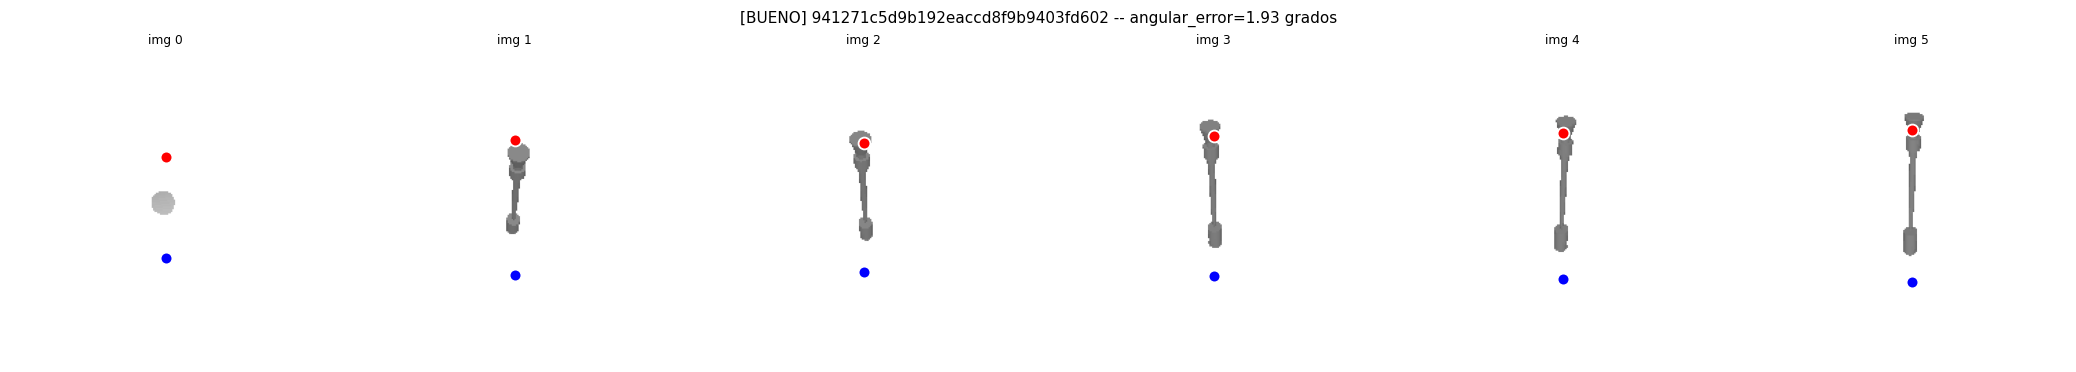

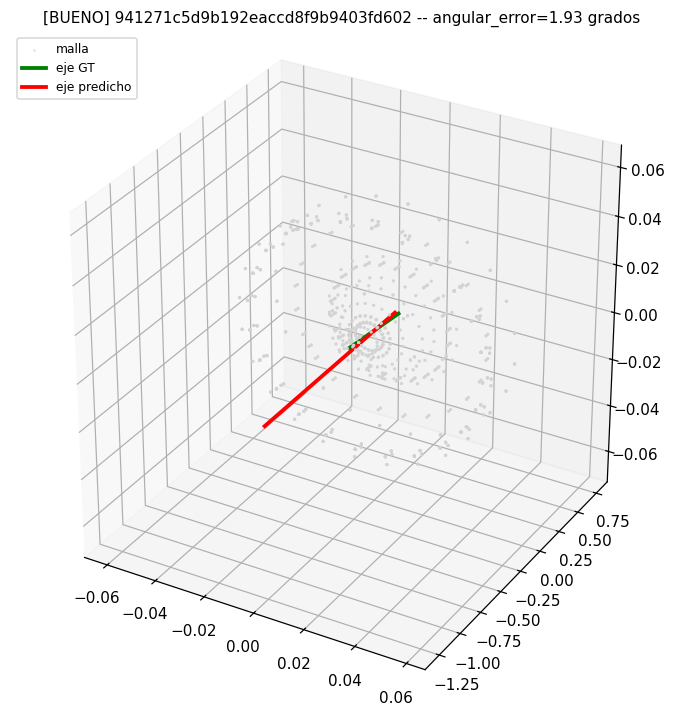

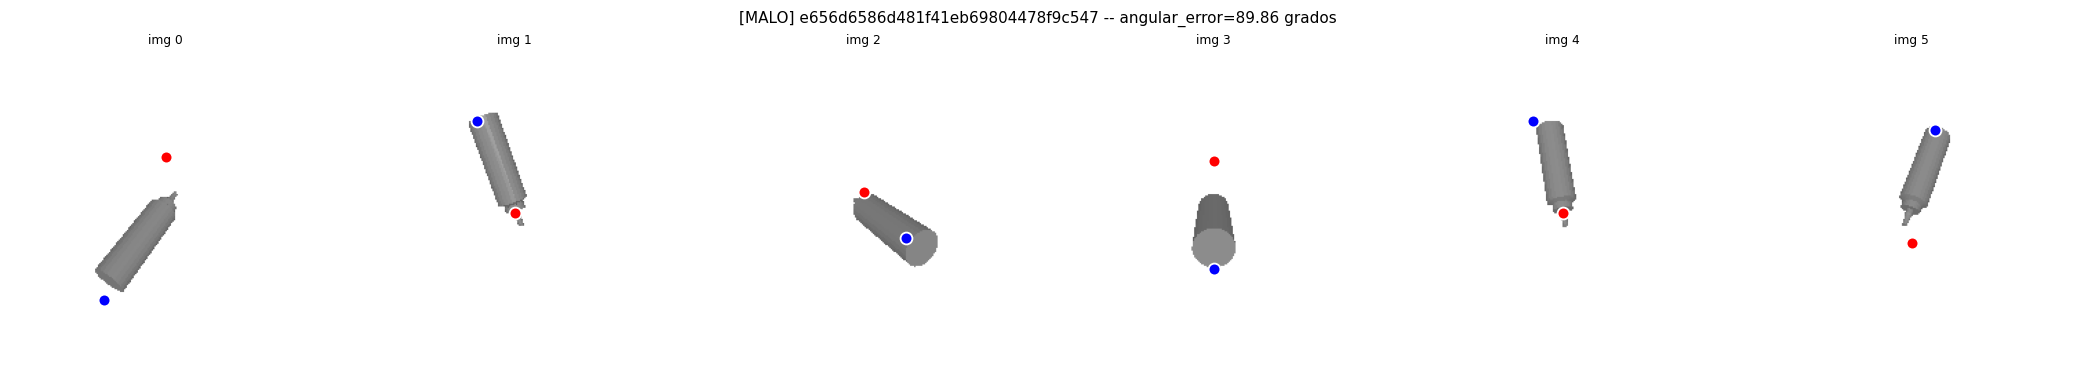

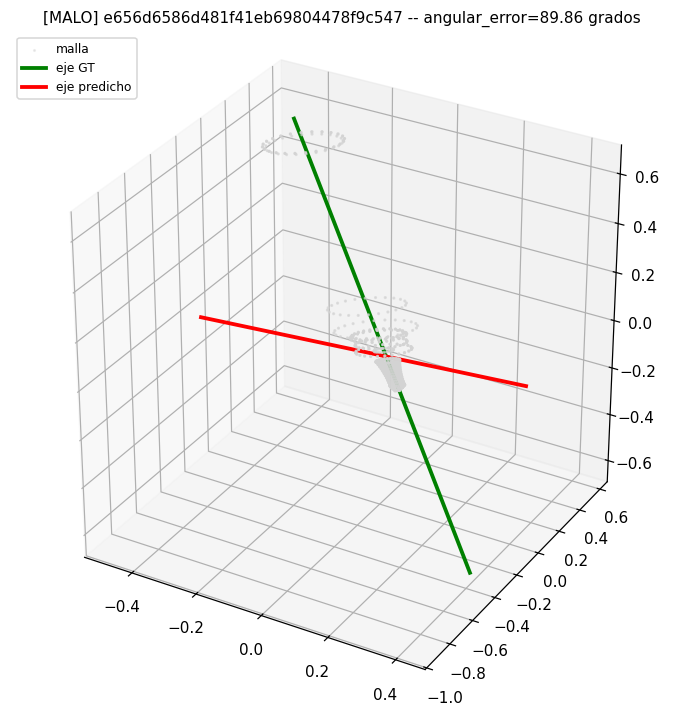

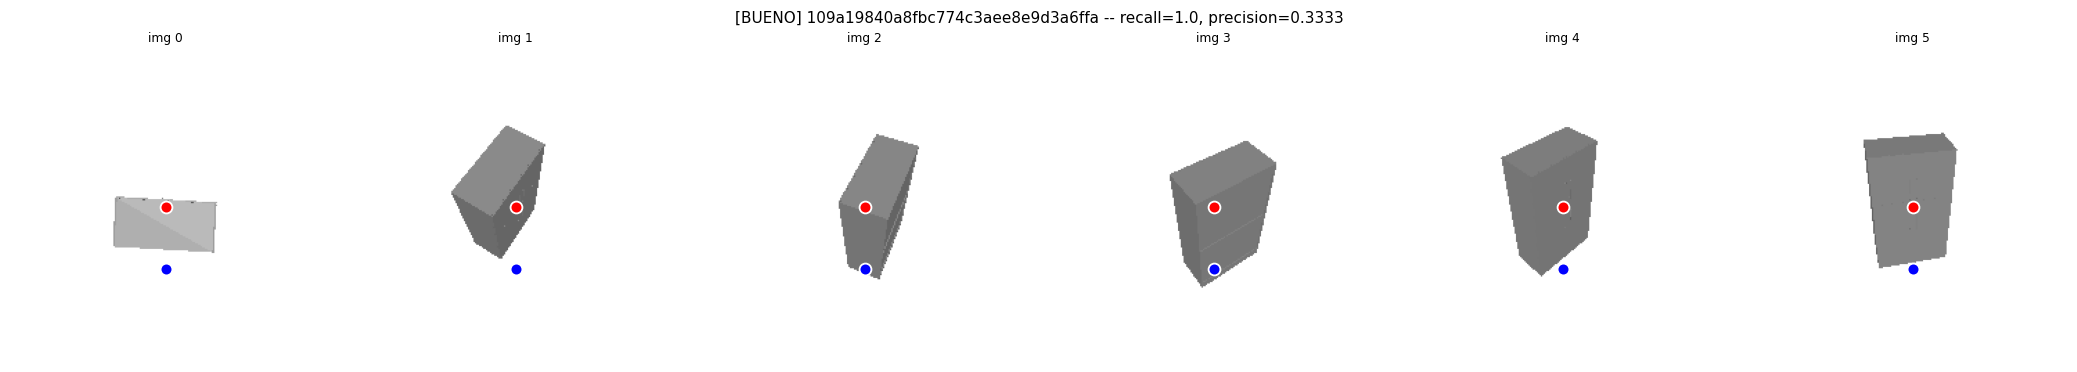

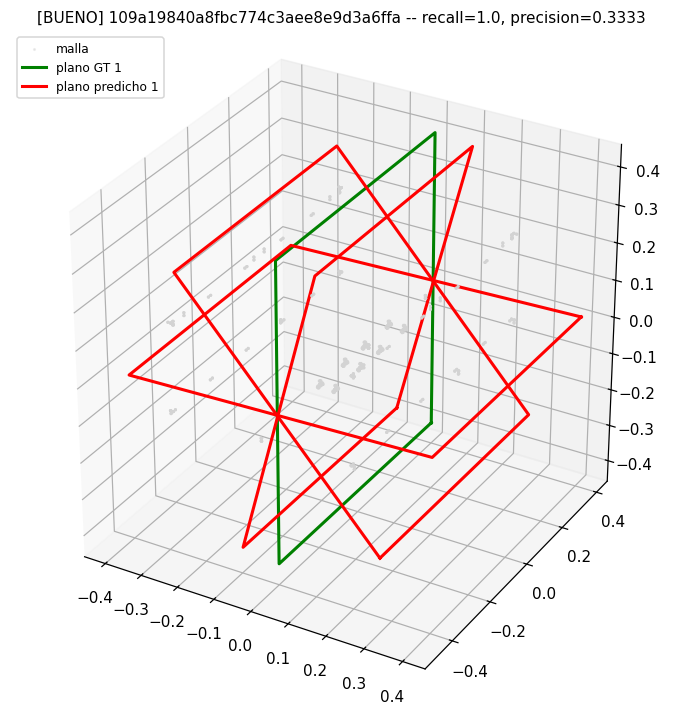

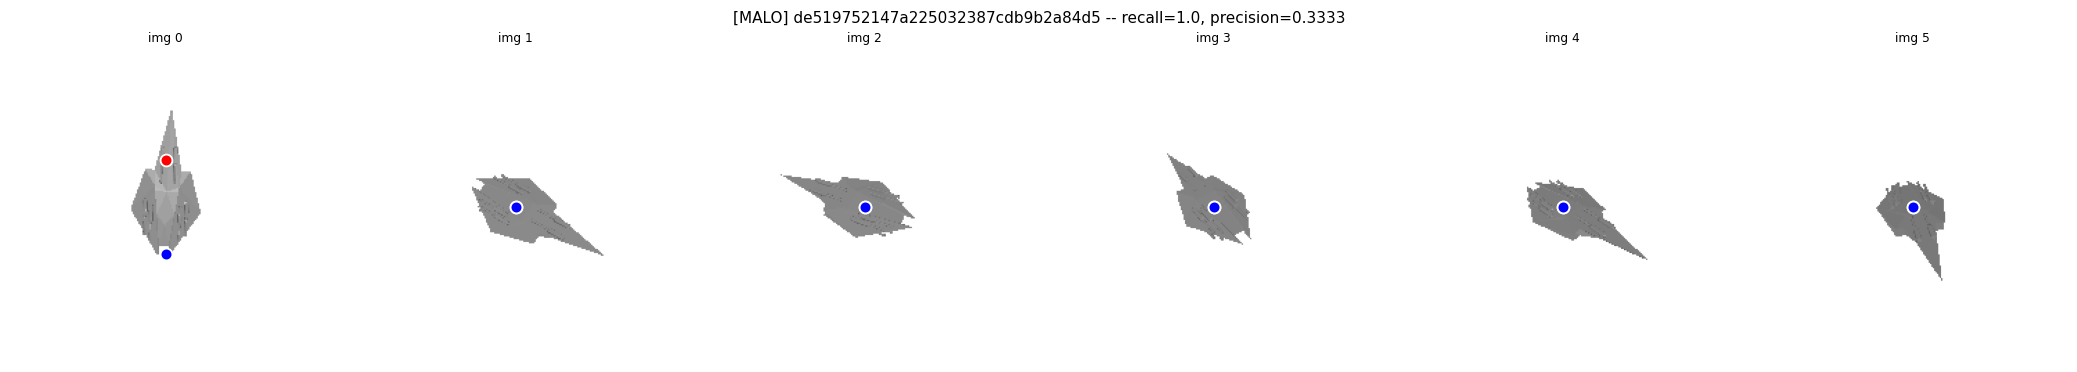

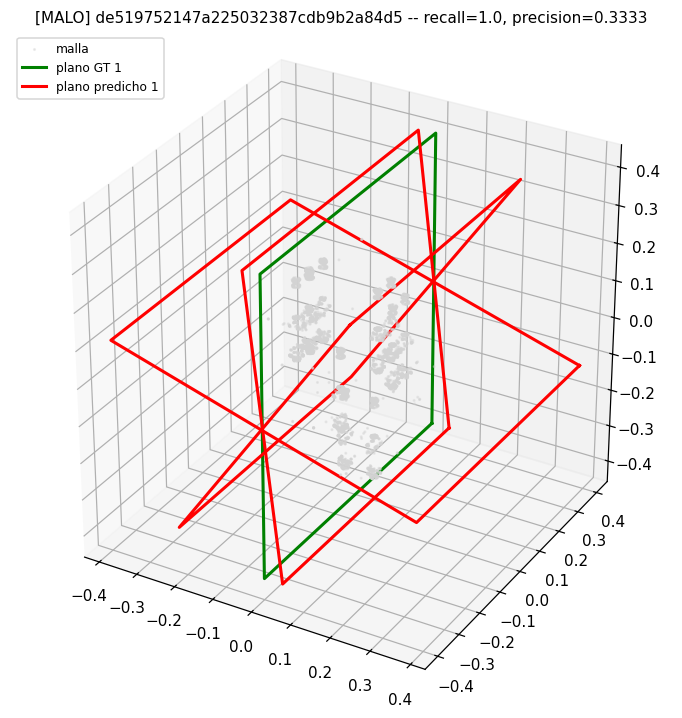

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


def _plot_2d(symmetry_type: str, object_id: str, categoria: str, experiment_id: str,
            n_views: int, subtitle: str, max_views_2d: int = 6) -> None:
    render_dir = SANDBOX_RENDERS / symmetry_type / object_id / str(SIZE) / LIGHTING
    molmo_data = json.load(open(render_dir / f"molmo_multiview_{experiment_id}.json", encoding="utf-8"))
    group = molmo_data[str(n_views)]
    images_sent, points_by_image = group["images_sent"], group["points_by_image"]

    idxs = sorted(points_by_image.keys(), key=int)[:max_views_2d]
    fig, axes = plt.subplots(1, len(idxs), figsize=(3.2 * len(idxs), 3.4))
    if len(idxs) == 1:
        axes = [axes]
    for ax, idx_str in zip(axes, idxs):
        cam = images_sent[int(idx_str)]
        img_path = render_dir / cam["filename"]
        img = np.array(Image.open(img_path)) if img_path.exists() else None
        if img is not None:
            ax.imshow(img)
            img_h, img_w = img.shape[0], img.shape[1]
        else:
            img_w = img_h = SIZE
            ax.set_xlim(0, img_w); ax.set_ylim(img_h, 0)
        for p in points_by_image[idx_str]:
            px, py = molmo_xy_to_pixel(p["x"], p["y"], img_w, img_h)
            ax.scatter([px], [py], c="red" if p["obj_id"] == 1 else "blue",
                       s=60, edgecolors="white", linewidths=1.2, zorder=5)
        ax.set_title(f"img {idx_str}", fontsize=8)
        ax.axis("off")
    fig.suptitle(f"[{categoria}] {object_id} -- {subtitle}", fontsize=10)
    fig.tight_layout()
    plt.show()


def plot_axis_case(object_id: str, categoria: str, n_views: int) -> None:
    pred = predicted_axes.get((object_id, n_views))
    gt   = parse_true_label(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["axis_sym"] / f"{object_id}.txt")
    err  = df_eval_axis[(df_eval_axis.object_id == object_id) & (df_eval_axis.n_views == n_views)]["angular_error_deg"].iloc[0]
    _plot_2d("axis_sym", object_id, categoria, EXPERIMENT_ID_AXIS, n_views, f"angular_error={err:.2f} grados")

    mesh  = trimesh.load(str(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["axis_sym"] / f"{object_id}.obj"), force="mesh", process=False)
    verts = np.asarray(mesh.vertices)
    verts_plot = verts if len(verts) <= 4000 else verts[np.random.default_rng(0).choice(len(verts), 4000, replace=False)]
    bbox_diag = float(np.linalg.norm(verts.max(axis=0) - verts.min(axis=0)))

    fig = plt.figure(figsize=(6.5, 6.5))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(verts_plot[:, 0], verts_plot[:, 1], verts_plot[:, 2], s=1, c="lightgray", alpha=0.4, label="malla")

    def plot_line(origin, direction, color, label):
        d = np.array(direction) / np.linalg.norm(direction)
        o = np.array(origin)
        p0, p1 = o - d * bbox_diag * 0.75, o + d * bbox_diag * 0.75
        ax.plot([p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]], color=color, linewidth=2.5, label=label)

    plot_line(gt["elements"][0]["origin"], gt["elements"][0]["direction"], "green", "eje GT")
    if pred is not None:
        plot_line(pred["origin"], pred["direction"], "red", "eje predicho")
    ax.set_title(f"[{categoria}] {object_id} -- angular_error={err:.2f} grados", fontsize=10)
    ax.legend(loc="upper left", fontsize=8)
    ax.set_box_aspect([1, 1, 1])
    fig.tight_layout()
    plt.show()


def _plane_patch(origin, normal, size, color, label, ax):
    """Dibuja el plano como un cuadrado finito centrado en origin, para poder verlo en 3D."""
    normal = np.array(normal) / np.linalg.norm(normal)
    origin = np.array(origin)
    tmp = np.array([1.0, 0.0, 0.0]) if abs(normal[0]) < 0.9 else np.array([0.0, 1.0, 0.0])
    u = np.cross(normal, tmp); u /= np.linalg.norm(u)
    v = np.cross(normal, u)
    corners = [origin + s1 * size * u + s2 * size * v for s1 in (-1, 1) for s2 in (-1, 1)]
    corners = [corners[0], corners[1], corners[3], corners[2]]  # orden para que el poligono no se cruce
    xs, ys, zs = zip(*corners)
    ax.plot(list(xs) + [xs[0]], list(ys) + [ys[0]], list(zs) + [zs[0]], color=color, linewidth=2, label=label)


def plot_plane_case(object_id: str, categoria: str, n_views: int) -> None:
    planes = predicted_planes.get((object_id, n_views), [])
    gt     = parse_true_label(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["plane_sym"] / f"{object_id}.txt")
    row    = df_eval_plane[(df_eval_plane.object_id == object_id) & (df_eval_plane.n_views == n_views)].iloc[0]
    _plot_2d("plane_sym", object_id, categoria, EXPERIMENT_ID_PLANE, n_views,
             f"recall={row['recall_planes']}, precision={row['precision_planes']}")

    mesh  = trimesh.load(str(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["plane_sym"] / f"{object_id}.obj"), force="mesh", process=False)
    verts = np.asarray(mesh.vertices)
    verts_plot = verts if len(verts) <= 4000 else verts[np.random.default_rng(0).choice(len(verts), 4000, replace=False)]
    bbox_diag = float(np.linalg.norm(verts.max(axis=0) - verts.min(axis=0)))

    fig = plt.figure(figsize=(6.5, 6.5))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(verts_plot[:, 0], verts_plot[:, 1], verts_plot[:, 2], s=1, c="lightgray", alpha=0.4, label="malla")

    for i, e in enumerate(gt["elements"]):
        _plane_patch(e["origin"], e["normal"], bbox_diag * 0.4, "green", f"plano GT {i+1}" if i == 0 else None, ax)
    for i, p in enumerate(planes):
        _plane_patch(p["origin"], p["normal"], bbox_diag * 0.4, "red", f"plano predicho {i+1}" if i == 0 else None, ax)

    ax.set_title(f"[{categoria}] {object_id} -- recall={row['recall_planes']}, precision={row['precision_planes']}", fontsize=10)
    ax.legend(loc="upper left", fontsize=8)
    ax.set_box_aspect([1, 1, 1])
    fig.tight_layout()
    plt.show()


# Ejemplo: un BUENO y un MALO de cada tipo, al mayor n_views
plot_axis_case(OBJECT_LIST_AXIS[0][1], "BUENO", n_views=max(VIEW_GROUPS))
plot_axis_case(OBJECT_LIST_AXIS[-1][1], "MALO", n_views=max(VIEW_GROUPS))
plot_plane_case(OBJECT_LIST_PLANE[0][1], "BUENO", n_views=max(VIEW_GROUPS))
plot_plane_case(OBJECT_LIST_PLANE[-1][1], "MALO", n_views=max(VIEW_GROUPS))

---
## 10. Ablaciones de triangulación y consolidación

Experimentos independientes sobre los datos ya inferidos por Molmo2 (no
requieren volver a correr el modelo). Cada ablación puede activarse/desactivarse
de forma aislada. La evaluación usa las mismas funciones y mallas de la
Sección 8 (`mesh_cache_axis`, `mesh_cache_plane`, `calaxisloss`, `calplaneloss`,
`f1_match_counts`) para que los resultados sean directamente comparables con el baseline.

| ID | Tipo | Qué cambia | Referencia |
|----|------|-----------|-----------|
| **EXP-A** | eje + plano | Triangulación ponderada por longitud 2D | Bartoli & Sturm, CVIU 2005 |
| **EXP-B** | eje | Point-then-Direction (ancla + dirección separados) | Wu et al., PMC 2021 |
| **EXP-C** | eje + plano | Filtro objeto + RANSAC 2D (diseñado para ≥6 pts/vista) | Recker et al., WACV 2013 |
| **EXP-D** | eje + plano | Confianza proxy: longitud × penalización de borde | AssemblyHands-X arXiv:2509.23888 |
| **EXP-E** | eje | Reweighting iterativo por residual de reproyección | Hess-Flores et al. eScholarship |
| **EXP-F** | plano | Pipeline 3-tier con parada por SDE_ref real | Gao et al. TVCG 2021 (adaptado) |


### 10.0 Helpers y evaluadores compartidos

In [ ]:
# ── Helpers compartidos para todas las ablaciones ──────────────────────────
import itertools

def auc_angular(errors_deg: list, max_theta: float = 45.0) -> float:
    thetas = np.linspace(0, max_theta, 1000)
    errs = np.array(errors_deg)
    precs = [(errs <= t).mean() for t in thetas]
    return float(np.trapezoid(precs, thetas) / max_theta)


def _eval_axis_row(cat, oid, n_views, pred, t_dir, t_orig, mesh_v, mesh_f, sample):
    """Build one eval row for an axis prediction (or None)."""
    row = {"categoria": cat, "object_id": oid, "n_views": n_views}
    if pred is None:
        row.update({"angular_error_deg": 90.0, "translation_error": None, "sde_ref": None})
    else:
        p_dir  = np.array(pred["direction"])
        p_orig = np.array(pred["origin"])
        ang  = angular_error_deg(p_dir, t_dir)
        dist = point_to_line_distance(p_orig, t_orig, t_dir)
        sde  = calaxisloss(p_dir, p_orig, mesh_v, mesh_f, sample)
        row.update({"angular_error_deg": round(ang, 4),
                    "translation_error": round(dist, 6),
                    "sde_ref": round(sde, 8)})
        for t in ANGULAR_THRESHOLDS:
            row[f"precision_{t}deg"] = int(ang < t)
    return row


def _eval_plane_row(cat, oid, n_views, planes, true_elements, mesh_v, mesh_f, sample, gt_planes_ref):
    """Build one eval row for a plane prediction list (or [])."""
    row = {"categoria": cat, "object_id": oid, "n_views": n_views,
           "n_true_planes": len(true_elements)}
    if not planes:
        row.update({"recall_planes": 0.0, "precision_planes": None,
                    "n_planes_predicted": 0, "sde_ref": None, "f1_counts": None})
    else:
        m = evaluate_plane_multiset(planes, true_elements, angular_threshold_deg=ANGULAR_THRESHOLDS[-1])
        pred_planes_ref = [normal_origin_to_plane(p["normal"], p["origin"]) for p in planes]
        sde_per_plane   = [calplaneloss(pp, mesh_v, mesh_f, sample) for pp in pred_planes_ref]
        f1_counts = {t: f1_match_counts(pred_planes_ref, gt_planes_ref, t) for t in THRESHOLDS_INLIER}
        row.update({"status": "ok", **m,
                    "sde_ref": round(float(np.mean(sde_per_plane)), 8),
                    "f1_counts": f1_counts})
    return row


def summarize_axis(label: str, rows: list) -> pd.DataFrame:
    df = pd.DataFrame(rows)
    df["angular_error_deg"] = df["angular_error_deg"].fillna(90.0)
    summary = df.groupby("n_views")["angular_error_deg"].agg(
        mean="mean", median="median", std="std").round(2)
    for t in ANGULAR_THRESHOLDS:
        col = f"precision_{t}deg"
        if col in df.columns:
            summary[f"P@{t}°"] = df.groupby("n_views")[col].mean().round(4)
    auc_map = {nv: round(auc_angular(g["angular_error_deg"].tolist()), 4)
               for nv, g in df.groupby("n_views")}
    summary["AUC@45°"] = pd.Series(auc_map)
    if "sde_ref" in df.columns:
        summary["SDE_ref_mean"] = df.groupby("n_views")["sde_ref"].mean().round(8)
    print(f"\n{'='*64}\n  {label}\n{'='*64}")
    print(summary.to_string())
    return summary


def summarize_plane(label: str, rows: list) -> pd.DataFrame:
    df = pd.DataFrame(rows)
    totals_by_nv = {}
    for nv, grp in df.groupby("n_views"):
        totals = {t: [0, 0, 0] for t in THRESHOLDS_INLIER}
        for fc in grp["f1_counts"].dropna():
            for t in THRESHOLDS_INLIER:
                tp, fp, fn = fc[str(t)] if isinstance(list(fc.keys())[0], str) else fc[t]
                totals[t][0] += tp; totals[t][1] += fp; totals[t][2] += fn
        f1_per_t = [f1_from_counts(*totals[t]) for t in THRESHOLDS_INLIER]
        totals_by_nv[nv] = round(float(np.mean(f1_per_t)), 4)
    summary = df.groupby("n_views")[["recall_planes", "precision_planes", "sde_ref"]].mean().round(4)
    summary["f1_ref"]          = pd.Series(totals_by_nv)
    summary["n_pred_mean"]     = df.groupby("n_views")["n_planes_predicted"].mean().round(2)
    print(f"\n{'='*64}\n  {label}\n{'='*64}")
    print(summary.to_string())
    return summary


### 10.1 Nuevas funciones de triangulación (compartidas por A–F)

In [ ]:
# ── Triangulación ponderada (Bartoli & Sturm 2005) ──────────────────────────
def triangulate_line_weighted(camera_centers: list, plane_normals: list,
                               weights: list) -> tuple[np.ndarray, np.ndarray]:
    """
    Weighted interpretation-plane triangulation.
    M = sum_i w_i * n_i n_i^T; direction = eigvec of MIN eigenvalue (axis).
    Ref: Bartoli & Sturm, CVIU 2005. DOI:10.1016/j.cviu.2005.06.001
    """
    N  = np.asarray(plane_normals, dtype=np.float64)
    C  = np.asarray(camera_centers, dtype=np.float64)
    w  = np.asarray(weights, dtype=np.float64); w = w / w.sum()
    M  = (N * w[:, None]).T @ N
    _, _, Vt = np.linalg.svd(M)
    direction = Vt[-1]; direction /= np.linalg.norm(direction)
    A = (np.diag(w) @ N)
    b = np.einsum("ij,ij->i", N, C) * w
    point, *_ = np.linalg.lstsq(A, b, rcond=None)
    return point, direction


def triangulate_plane_weighted(camera_centers: list, plane_normals: list,
                                weights: list) -> tuple[np.ndarray, np.ndarray]:
    """
    Same as above but uses MAX eigenvalue — for plane symmetry (dual).
    The symmetry plane's normal is the direction of LEAST spread of interpretation normals.
    """
    N  = np.asarray(plane_normals, dtype=np.float64)
    C  = np.asarray(camera_centers, dtype=np.float64)
    w  = np.asarray(weights, dtype=np.float64); w = w / w.sum()
    M  = (N * w[:, None]).T @ N
    _, _, Vt = np.linalg.svd(M)
    normal = Vt[0]; normal /= np.linalg.norm(normal)   # MAX eigenvalue for plane
    origin = np.average(C, weights=w, axis=0)
    return origin, normal


# ── Midpoint triangulation (pair-wise) ───────────────────────────────────────
def midpoint_triangulate_pair(o1: np.ndarray, d1: np.ndarray,
                               o2: np.ndarray, d2: np.ndarray) -> np.ndarray:
    w = o1 - o2
    a, b, c_, d, e = (d1@d1, d1@d2, d2@d2, d1@w, d2@w)
    denom = a * c_ - b * b
    if abs(denom) < 1e-9:
        return (o1 + o2) / 2.0
    s = (b * e - c_ * d) / denom
    t = (a * e - b  * d) / denom
    return ((o1 + s * d1) + (o2 + t * d2)) / 2.0


# ── RANSAC 2D line fitting (Recker et al. WACV 2013) ────────────────────────
RANSAC_THR_PX  = 8.0
RANSAC_N_ITER  = 100
RANSAC_MIN_PTS = 4

def fit_line_ransac_2d(points_xy: list, n_iter=RANSAC_N_ITER, thr_px=RANSAC_THR_PX,
                        min_inliers=RANSAC_MIN_PTS, rng=None):
    """
    RANSAC 2D line fitting. Returns (inlier_points, seg_length) or None.
    Ref: Recker et al. WACV 2013. https://sites.google.com/view/mauriciohessflores
    """
    if rng is None: rng = np.random.default_rng(42)
    pts = np.array(points_xy, dtype=np.float64)
    n = len(pts)
    if n < 2: return None
    if n == 2:
        seg = float(np.linalg.norm(pts[1] - pts[0]))
        return points_xy, seg
    best_inliers, best_seg = [], 0.0
    for _ in range(n_iter):
        i, j = rng.choice(n, size=2, replace=False)
        diff = pts[j] - pts[i]
        if np.linalg.norm(diff) < 1e-3: continue
        a, b_ = -diff[1], diff[0]
        c_ = -(a * pts[i,0] + b_ * pts[i,1])
        norm_ab = (a*a + b_*b_) ** 0.5
        dists = np.abs(a * pts[:,0] + b_ * pts[:,1] + c_) / norm_ab
        mask = dists < thr_px
        if mask.sum() > len(best_inliers):
            inlier_pts = pts[mask]
            dir_n = diff / np.linalg.norm(diff)
            projs = inlier_pts @ dir_n
            best_seg = float(projs.max() - projs.min())
            best_inliers = [tuple(p) for p in inlier_pts]
    if len(best_inliers) < min_inliers: return None
    return best_inliers, best_seg


def widest_pair_from_inliers(inlier_pts: list):
    pts = np.array(inlier_pts)
    best = (-1.0, 0, 1)
    for i in range(len(pts)):
        for j in range(i+1, len(pts)):
            d = float(np.sum((pts[i]-pts[j])**2))
            if d > best[0]: best = (d, i, j)
    _, i, j = best
    return ({"x": float(pts[i,0]), "y": float(pts[i,1])},
            {"x": float(pts[j,0]), "y": float(pts[j,1])},
            best[0]**0.5)


# ── Border margin proxy (AssemblyHands-X arXiv:2509.23888) ──────────────────
BORDER_MARGIN_PX = 20

def border_margin_px(x: float, y: float, image_size: int) -> float:
    px = (x / 1000.0) * image_size
    py = (y / 1000.0) * image_size
    return float(min(px, py, image_size - px, image_size - py))


### EXP-A — Triangulación ponderada por longitud 2D
*(Bartoli & Sturm, CVIU 2005. DOI:10.1016/j.cviu.2005.06.001)*

**Motivación**: en la triangulación baseline todos los planos de interpretación
pesan igual. Una vista donde los dos puntos predichos están a 5 px de distancia
contribuye igual que una donde están a 200 px, aunque la primera es mucho más
sensible a ruido. El peso $w_i = \|p_a^{(i)} - p_b^{(i)}\|_2$ corrige esto.


In [ ]:
# ── EXP-A: estimadores ─────────────────────────────────────────────────────
def estimate_axis_weighted(points_by_image, images_sent, fov_deg, image_size):
    """EXP-A eje: widest_pair + weight = 2D segment length (px)."""
    centers, normals, weights = [], [], []
    for img_idx_str, pts in points_by_image.items():
        pair = widest_pair(pts)
        if pair is None: continue
        p_a, p_b = pair
        cam = images_sent[int(img_idx_str)]
        C, d_a = ray_dir_for_point(p_a["x"], p_a["y"], cam["R"], cam["T"], fov_deg, image_size)
        _, d_b  = ray_dir_for_point(p_b["x"], p_b["y"], cam["R"], cam["T"], fov_deg, image_size)
        n = interpretation_plane_normal(d_a, d_b)
        if n is None: continue
        seg = ((p_a["x"]-p_b["x"])**2 + (p_a["y"]-p_b["y"])**2)**0.5
        centers.append(C); normals.append(n); weights.append(max(seg, 1e-3))
    if len(normals) < 2:
        raise ValueError(f"EXP-A eje: need >=2, got {len(normals)}")
    point, direction = triangulate_line_weighted(centers, normals, weights)
    return {"direction": direction.tolist(), "origin": point.tolist(), "n_views_used": len(normals)}


def estimate_plane_weighted(points_by_image, images_sent, fov_deg, image_size,
                             edge_on_thresh=EDGE_ON_THRESH_DEFAULT,
                             max_planes=MAX_PLANES, dup_angle_thresh_deg=DUP_ANGLE_THRESH_DEFAULT):
    """EXP-A plano: misma lógica que detect_planes_no_mesh pero la normal del refit
    se pesa por la longitud de segmento del par de vistas que generó cada línea."""
    def _ang(v1, v2):
        return float(np.degrees(np.arccos(np.clip(abs(float(np.dot(
            v1/np.linalg.norm(v1), v2/np.linalg.norm(v2)))), 0.0, 1.0))))

    def _run_one(pts_by_img):
        view_idxs = sorted(int(k) for k, pts in pts_by_img.items()
                           if get_point_by_obj_id(pts, 1) is not None
                           and get_point_by_obj_id(pts, 2) is not None)
        if len(view_idxs) < 4: raise ValueError("need >=4 views")
        pair_lines, pair_weights = [], []
        for i, j in combinations(view_idxs, 2):
            res = _line_from_view_pair(i, j, pts_by_img, images_sent, fov_deg, image_size)
            if res is None: continue
            point, direction = res
            # weight = geometric mean of segment lengths in the two views
            segs = []
            for idx in (i, j):
                pts = pts_by_img.get(str(idx), [])
                p1, p2 = get_point_by_obj_id(pts, 1), get_point_by_obj_id(pts, 2)
                if p1 and p2:
                    segs.append(((p1["x"]-p2["x"])**2 + (p1["y"]-p2["y"])**2)**0.5)
            w = (segs[0]*segs[1])**0.5 if len(segs)==2 else 1.0
            pair_lines.append(((i, j), point, direction)); pair_weights.append(max(w, 1e-3))
        if len(pair_lines) < 2: raise ValueError("not enough pair-lines")
        view_dirs = {idx: view_forward_direction(
            images_sent[idx]["R"], images_sent[idx]["T"], fov_deg, image_size)
                     for idx in view_idxs}
        def score_normal(n):
            vals = sorted(abs(np.dot(view_dirs[i], n)) for i in view_idxs)
            return float(np.mean(vals[:max(2, len(vals)//2)]))
        candidates = []
        for a_ in range(len(pair_lines)):
            for b_ in range(a_+1, len(pair_lines)):
                pa, _, dir_a = pair_lines[a_]
                pb, _, dir_b = pair_lines[b_]
                if set(pa) & set(pb): continue
                n = np.cross(dir_a, dir_b)
                nrm = np.linalg.norm(n)
                if nrm < 1e-6: continue
                candidates.append(n / nrm)
        if not candidates: raise ValueError("no candidates")
        scored = sorted(candidates, key=score_normal)
        best_normal = scored[0]
        good_views = [i for i in view_idxs
                      if abs(np.dot(view_dirs[i], best_normal)) < edge_on_thresh]
        # Weighted refit: weight each pair_line by its segment weight
        refit_dirs, refit_weights = [], []
        for (pa, _, d), w in zip(pair_lines, pair_weights):
            if set(pa).issubset(good_views):
                refit_dirs.append(d); refit_weights.append(w)
        refit_points = [p for (pa, p, _) in pair_lines if set(pa).issubset(good_views)]
        if len(refit_dirs) >= 2:
            D = np.asarray(refit_dirs); W = np.asarray(refit_weights); W /= W.sum()
            M = (D * W[:, None]).T @ D
            _, _, Vt = np.linalg.svd(M)
            refined_normal = Vt[-1]; refined_normal /= np.linalg.norm(refined_normal)
            used_points = refit_points
        else:
            refined_normal, used_points = best_normal, [p for (_, p, _) in pair_lines]
        origin = np.mean(used_points, axis=0)
        return {"normal": refined_normal.tolist(), "origin": origin.tolist(),
                "n_views_used": len(good_views), "good_views": good_views}

    all_view_idxs = sorted(int(k) for k, pts in points_by_image.items()
                           if get_point_by_obj_id(pts, 1) is not None
                           and get_point_by_obj_id(pts, 2) is not None)
    pool, planes = set(all_view_idxs), []
    while len(planes) < max_planes:
        if len(pool) < 4: break
        sub = {k: v for k, v in points_by_image.items() if int(k) in pool}
        try:
            pred = _run_one(sub)
        except ValueError:
            break
        normal = np.array(pred["normal"])
        if any(_ang(normal, np.array(p["normal"])) < dup_angle_thresh_deg for p in planes):
            break
        planes.append(pred); pool -= set(pred["good_views"])
    return planes


# ── EXP-A: evaluación eje ──────────────────────────────────────────────────
rows_A_axis = []
for cat, oid in OBJECT_LIST_AXIS:
    gt = parse_true_label(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["axis_sym"] / f"{oid}.txt")
    t_dir, t_orig = np.array(gt["elements"][0]["direction"]), np.array(gt["elements"][0]["origin"])
    mesh_v, mesh_f, sample = mesh_cache_axis[oid]
    render_dir = SANDBOX_RENDERS / "axis_sym" / oid / str(SIZE) / LIGHTING
    molmo_data = json.load(open(render_dir / f"molmo_multiview_{EXPERIMENT_ID_AXIS}.json"))
    for n_views in VIEW_GROUPS:
        group = molmo_data.get(str(n_views), {})
        try:
            pred = estimate_axis_weighted(group.get("points_by_image",{}), group.get("images_sent",[]), DEFAULT_FOV, SIZE)
        except ValueError: pred = None
        rows_A_axis.append(_eval_axis_row(cat, oid, n_views, pred, t_dir, t_orig, mesh_v, mesh_f, sample))

summary_A_axis = summarize_axis("EXP-A EJE: Triangulación ponderada (Bartoli & Sturm CVIU 2005)", rows_A_axis)

# ── EXP-A: evaluación plano ────────────────────────────────────────────────
rows_A_plane = []
for cat, oid in OBJECT_LIST_PLANE:
    gt = parse_true_label(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["plane_sym"] / f"{oid}.txt")
    true_elements = gt["elements"]
    mesh_v, mesh_f, sample, gt_planes_ref = mesh_cache_plane[oid]
    render_dir = SANDBOX_RENDERS / "plane_sym" / oid / str(SIZE) / LIGHTING
    molmo_data = json.load(open(render_dir / f"molmo_multiview_{EXPERIMENT_ID_PLANE}.json"))
    for n_views in VIEW_GROUPS:
        group = molmo_data.get(str(n_views), {})
        try:
            planes = estimate_plane_weighted(group.get("points_by_image",{}), group.get("images_sent",[]),
                                             DEFAULT_FOV, SIZE)
        except (ValueError, Exception): planes = []
        rows_A_plane.append(_eval_plane_row(cat, oid, n_views, planes, true_elements, mesh_v, mesh_f, sample, gt_planes_ref))

summary_A_plane = summarize_plane("EXP-A PLANO: Triangulación ponderada (Bartoli & Sturm CVIU 2005)", rows_A_plane)


### EXP-B — Point-then-Direction (eje únicamente)
*(Wu et al., PMC 2021. https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7832884/)*

Separa la estimación en dos subproblemas: (1) punto ancla via promedio ponderado
de midpoint-triangulations entre pares de vistas; (2) dirección via SVD ponderado
sobre los planos de interpretación centrados en ese ancla.


In [ ]:
# ── EXP-B: Point-then-Direction (eje) ──────────────────────────────────────
def estimate_axis_ptd(points_by_image, images_sent, fov_deg, image_size):
    """EXP-B eje: Point-then-Direction. Ref: Wu et al. PMC 2021."""
    view_data = []
    for img_idx_str, pts in points_by_image.items():
        pair = widest_pair(pts)
        if pair is None: continue
        p_a, p_b = pair
        cam = images_sent[int(img_idx_str)]
        C, d_a = ray_dir_for_point(p_a["x"], p_a["y"], cam["R"], cam["T"], fov_deg, image_size)
        _, d_b  = ray_dir_for_point(p_b["x"], p_b["y"], cam["R"], cam["T"], fov_deg, image_size)
        n = interpretation_plane_normal(d_a, d_b)
        if n is None: continue
        seg = ((p_a["x"]-p_b["x"])**2 + (p_a["y"]-p_b["y"])**2)**0.5
        d_mid = (d_a + d_b); d_mid /= np.linalg.norm(d_mid)
        view_data.append({"C": C, "d_mid": d_mid, "n": n, "seg": seg})
    if len(view_data) < 2:
        raise ValueError(f"EXP-B: need >=2, got {len(view_data)}")
    # Step 1: anchor via weighted pairwise midpoints
    anchor_pts = []
    for i, j in itertools.combinations(range(len(view_data)), 2):
        vi, vj = view_data[i], view_data[j]
        mp = midpoint_triangulate_pair(vi["C"], vi["d_mid"], vj["C"], vj["d_mid"])
        w  = (vi["seg"] * vj["seg"]) ** 0.5
        anchor_pts.append((mp, w))
    total_w = sum(w for _, w in anchor_pts)
    anchor = sum(mp * w for mp, w in anchor_pts) / total_w
    # Step 2: direction via weighted SVD on interpretation planes
    normals = np.array([v["n"] for v in view_data])
    weights = np.array([max(v["seg"], 1e-3) for v in view_data]); weights /= weights.sum()
    M = (normals * weights[:, None]).T @ normals
    _, _, Vt = np.linalg.svd(M)
    direction = Vt[-1]; direction /= np.linalg.norm(direction)
    return {"direction": direction.tolist(), "origin": anchor.tolist(),
            "n_views_used": len(view_data)}


rows_B_axis = []
for cat, oid in OBJECT_LIST_AXIS:
    gt = parse_true_label(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["axis_sym"] / f"{oid}.txt")
    t_dir, t_orig = np.array(gt["elements"][0]["direction"]), np.array(gt["elements"][0]["origin"])
    mesh_v, mesh_f, sample = mesh_cache_axis[oid]
    render_dir = SANDBOX_RENDERS / "axis_sym" / oid / str(SIZE) / LIGHTING
    molmo_data = json.load(open(render_dir / f"molmo_multiview_{EXPERIMENT_ID_AXIS}.json"))
    for n_views in VIEW_GROUPS:
        group = molmo_data.get(str(n_views), {})
        try:
            pred = estimate_axis_ptd(group.get("points_by_image",{}), group.get("images_sent",[]), DEFAULT_FOV, SIZE)
        except ValueError: pred = None
        rows_B_axis.append(_eval_axis_row(cat, oid, n_views, pred, t_dir, t_orig, mesh_v, mesh_f, sample))

summary_B_axis = summarize_axis("EXP-B EJE: Point-then-Direction (Wu et al. PMC 2021)", rows_B_axis)


### EXP-C — Filtro objeto + RANSAC 2D
*(Recker et al. WACV 2013; Zhang et al. arXiv:2008.01258)*

Aplica filtro de píxeles de objeto y luego RANSAC 2D para ajustar una línea robusta
a los puntos de cada vista antes de formar el plano de interpretación. Con los
prompts actuales de 2 puntos, el efecto es idéntico al del filtro de objeto solo
(sin outliers extra). Con prompts de ≥6 puntos, RANSAC elimina los puntos ruidosos
antes de la triangulación.


In [ ]:
# ── EXP-C: Filtro objeto + RANSAC 2D ───────────────────────────────────────
FILTER_OBJECT_C = True   # False para aislar solo el efecto del RANSAC 2D

def estimate_axis_ransac(points_by_image, images_sent, fov_deg, image_size,
                          render_dir, filter_object=True, image_cache=None):
    """EXP-C eje: filter object pixels, RANSAC 2D line, weighted triangulation."""
    if image_cache is None: image_cache = {}
    pts_filt = filter_points_on_object(
        points_by_image, images_sent, render_dir, min_points=2, image_cache=image_cache
    ) if filter_object else points_by_image
    rng = np.random.default_rng(0)
    centers, normals, weights = [], [], []
    for img_idx_str, pts in pts_filt.items():
        if not pts: continue
        xy = [(p["x"], p["y"]) for p in pts]
        result = fit_line_ransac_2d(xy, rng=rng)
        if result is None: continue
        inliers, _ = result
        p_a, p_b, seg_px = widest_pair_from_inliers(inliers)
        cam = images_sent[int(img_idx_str)]
        C, d_a = ray_dir_for_point(p_a["x"], p_a["y"], cam["R"], cam["T"], fov_deg, image_size)
        _, d_b  = ray_dir_for_point(p_b["x"], p_b["y"], cam["R"], cam["T"], fov_deg, image_size)
        n = interpretation_plane_normal(d_a, d_b)
        if n is None: continue
        centers.append(C); normals.append(n); weights.append(max(seg_px, 1e-3))
    if len(normals) < 2:
        raise ValueError(f"EXP-C eje: need >=2, got {len(normals)}")
    point, direction = triangulate_line_weighted(centers, normals, weights)
    return {"direction": direction.tolist(), "origin": point.tolist(), "n_views_used": len(normals)}


def detect_planes_ransac(points_by_image, images_sent, fov_deg, image_size,
                          render_dir, filter_object=True, image_cache=None,
                          max_planes=MAX_PLANES, edge_on_thresh=EDGE_ON_THRESH_DEFAULT,
                          dup_angle_thresh_deg=DUP_ANGLE_THRESH_DEFAULT):
    """EXP-C plano: filter + RANSAC 2D, then detect_planes_no_mesh on filtered pairs."""
    if image_cache is None: image_cache = {}
    pts_filt = filter_points_on_object(
        points_by_image, images_sent, render_dir, min_points=2, image_cache=image_cache
    ) if filter_object else points_by_image
    # Re-map to obj_id 1/2 from widest RANSAC inlier pair (preserves downstream API)
    pts_remapped = {}
    rng = np.random.default_rng(0)
    for img_idx_str, pts in pts_filt.items():
        if not pts: continue
        xy = [(p["x"], p["y"]) for p in pts]
        result = fit_line_ransac_2d(xy, rng=rng)
        if result is None: continue
        inliers, _ = result
        p_a, p_b, _ = widest_pair_from_inliers(inliers)
        pts_remapped[img_idx_str] = [
            {"obj_id": 1, "x": p_a["x"], "y": p_a["y"]},
            {"obj_id": 2, "x": p_b["x"], "y": p_b["y"]},
        ]
    if not pts_remapped:
        return []
    return detect_planes_no_mesh(pts_remapped, images_sent, fov_deg, image_size,
                                  edge_on_thresh, max_planes, dup_angle_thresh_deg)


# EXP-C eje
rows_C_axis = []
for cat, oid in OBJECT_LIST_AXIS:
    gt = parse_true_label(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["axis_sym"] / f"{oid}.txt")
    t_dir, t_orig = np.array(gt["elements"][0]["direction"]), np.array(gt["elements"][0]["origin"])
    mesh_v, mesh_f, sample = mesh_cache_axis[oid]
    render_dir = SANDBOX_RENDERS / "axis_sym" / oid / str(SIZE) / LIGHTING
    molmo_data = json.load(open(render_dir / f"molmo_multiview_{EXPERIMENT_ID_AXIS}.json"))
    img_cache = {}
    for n_views in VIEW_GROUPS:
        group = molmo_data.get(str(n_views), {})
        try:
            pred = estimate_axis_ransac(group.get("points_by_image",{}), group.get("images_sent",[]),
                                         DEFAULT_FOV, SIZE, render_dir,
                                         filter_object=FILTER_OBJECT_C, image_cache=img_cache)
        except ValueError: pred = None
        rows_C_axis.append(_eval_axis_row(cat, oid, n_views, pred, t_dir, t_orig, mesh_v, mesh_f, sample))

summary_C_axis = summarize_axis(f"EXP-C EJE: Filtro+RANSAC2D (Recker WACV 2013) | filter={FILTER_OBJECT_C}", rows_C_axis)

# EXP-C plano
rows_C_plane = []
for cat, oid in OBJECT_LIST_PLANE:
    gt = parse_true_label(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["plane_sym"] / f"{oid}.txt")
    true_elements = gt["elements"]
    mesh_v, mesh_f, sample, gt_planes_ref = mesh_cache_plane[oid]
    render_dir = SANDBOX_RENDERS / "plane_sym" / oid / str(SIZE) / LIGHTING
    molmo_data = json.load(open(render_dir / f"molmo_multiview_{EXPERIMENT_ID_PLANE}.json"))
    img_cache = {}
    for n_views in VIEW_GROUPS:
        group = molmo_data.get(str(n_views), {})
        try:
            planes = detect_planes_ransac(group.get("points_by_image",{}), group.get("images_sent",[]),
                                           DEFAULT_FOV, SIZE, render_dir,
                                           filter_object=FILTER_OBJECT_C, image_cache=img_cache)
        except (ValueError, Exception): planes = []
        rows_C_plane.append(_eval_plane_row(cat, oid, n_views, planes, true_elements, mesh_v, mesh_f, sample, gt_planes_ref))

summary_C_plane = summarize_plane(f"EXP-C PLANO: Filtro+RANSAC2D (Recker WACV 2013) | filter={FILTER_OBJECT_C}", rows_C_plane)


### EXP-D — Confianza proxy: longitud 2D × penalización de borde
*(AssemblyHands-X arXiv:2509.23888; COMPOSE arXiv:2601.09698)*

$w_i = \ell_i \cdot \min(1, m_i / \text{border\_margin})$ donde $m_i$ es la
distancia mínima al borde de imagen del punto más cercano al borde en la vista $i$.


In [ ]:
# ── EXP-D: confianza proxy ─────────────────────────────────────────────────
def _conf_weight(p_a, p_b, image_size):
    seg = ((p_a["x"]-p_b["x"])**2 + (p_a["y"]-p_b["y"])**2)**0.5
    m   = min(border_margin_px(p_a["x"], p_a["y"], image_size),
              border_margin_px(p_b["x"], p_b["y"], image_size))
    return max(seg, 1e-3) * min(1.0, m / BORDER_MARGIN_PX)


def estimate_axis_conf(points_by_image, images_sent, fov_deg, image_size):
    """EXP-D eje: weighted triangulation with border-proximity penalty."""
    centers, normals, weights = [], [], []
    for img_idx_str, pts in points_by_image.items():
        pair = widest_pair(pts)
        if pair is None: continue
        p_a, p_b = pair
        cam = images_sent[int(img_idx_str)]
        C, d_a = ray_dir_for_point(p_a["x"], p_a["y"], cam["R"], cam["T"], fov_deg, image_size)
        _, d_b  = ray_dir_for_point(p_b["x"], p_b["y"], cam["R"], cam["T"], fov_deg, image_size)
        n = interpretation_plane_normal(d_a, d_b)
        if n is None: continue
        centers.append(C); normals.append(n)
        weights.append(max(_conf_weight(p_a, p_b, image_size), 1e-6))
    if len(normals) < 2: raise ValueError(f"EXP-D eje: need >=2, got {len(normals)}")
    point, direction = triangulate_line_weighted(centers, normals, weights)
    return {"direction": direction.tolist(), "origin": point.tolist(), "n_views_used": len(normals)}


def estimate_plane_conf(points_by_image, images_sent, fov_deg, image_size,
                         edge_on_thresh=EDGE_ON_THRESH_DEFAULT, max_planes=MAX_PLANES,
                         dup_angle_thresh_deg=DUP_ANGLE_THRESH_DEFAULT):
    """EXP-D plano: misma lógica que estimate_plane_weighted pero weight = confianza proxy."""
    def _ang(v1, v2):
        return float(np.degrees(np.arccos(np.clip(abs(float(np.dot(
            v1/np.linalg.norm(v1), v2/np.linalg.norm(v2)))), 0.0, 1.0))))
    def _run_one(pts_by_img):
        view_idxs = sorted(int(k) for k, pts in pts_by_img.items()
                           if get_point_by_obj_id(pts,1) is not None
                           and get_point_by_obj_id(pts,2) is not None)
        if len(view_idxs) < 4: raise ValueError("need >=4 views")
        pair_lines, pair_weights = [], []
        for i, j in combinations(view_idxs, 2):
            res = _line_from_view_pair(i, j, pts_by_img, images_sent, fov_deg, image_size)
            if res is None: continue
            point, direction = res
            ws = []
            for idx in (i, j):
                pts_ = pts_by_img.get(str(idx), [])
                p1, p2 = get_point_by_obj_id(pts_, 1), get_point_by_obj_id(pts_, 2)
                if p1 and p2: ws.append(_conf_weight(p1, p2, image_size))
            w = (ws[0]*ws[1])**0.5 if len(ws)==2 else 1.0
            pair_lines.append(((i, j), point, direction)); pair_weights.append(max(w, 1e-6))
        if len(pair_lines) < 2: raise ValueError("not enough pair-lines")
        view_dirs = {idx: view_forward_direction(images_sent[idx]["R"], images_sent[idx]["T"], fov_deg, image_size)
                     for idx in view_idxs}
        scored = sorted([(abs(np.dot(view_dirs[i], np.cross(pair_lines[a][2], pair_lines[b][2])
                                     / (np.linalg.norm(np.cross(pair_lines[a][2], pair_lines[b][2])) + 1e-9))),
                          a, b)
                         for a in range(len(pair_lines)) for b in range(a+1, len(pair_lines))
                         if not set(pair_lines[a][0]) & set(pair_lines[b][0])])
        candidates = []
        for a_ in range(len(pair_lines)):
            for b_ in range(a_+1, len(pair_lines)):
                if set(pair_lines[a_][0]) & set(pair_lines[b_][0]): continue
                n = np.cross(pair_lines[a_][2], pair_lines[b_][2])
                nrm = np.linalg.norm(n)
                if nrm < 1e-6: continue
                candidates.append(n / nrm)
        if not candidates: raise ValueError("no candidates")
        def score_normal(n):
            vals = sorted(abs(np.dot(view_dirs[i], n)) for i in view_idxs)
            return float(np.mean(vals[:max(2, len(vals)//2)]))
        best_normal = sorted(candidates, key=score_normal)[0]
        good_views = [i for i in view_idxs if abs(np.dot(view_dirs[i], best_normal)) < edge_on_thresh]
        refit_dirs, refit_weights, refit_points = [], [], []
        for (pa, p, d), w in zip(pair_lines, pair_weights):
            if set(pa).issubset(good_views):
                refit_dirs.append(d); refit_weights.append(w); refit_points.append(p)
        if len(refit_dirs) >= 2:
            D = np.asarray(refit_dirs); W = np.asarray(refit_weights); W /= W.sum()
            M = (D * W[:,None]).T @ D
            _, _, Vt = np.linalg.svd(M)
            refined_normal = Vt[-1]; refined_normal /= np.linalg.norm(refined_normal)
            used_points = refit_points
        else:
            refined_normal, used_points = best_normal, [p for (_, p, _) in pair_lines]
        return {"normal": refined_normal.tolist(), "origin": np.mean(used_points, axis=0).tolist(),
                "n_views_used": len(good_views), "good_views": good_views}
    all_view_idxs = sorted(int(k) for k, pts in points_by_image.items()
                           if get_point_by_obj_id(pts,1) is not None
                           and get_point_by_obj_id(pts,2) is not None)
    pool, planes = set(all_view_idxs), []
    while len(planes) < max_planes:
        if len(pool) < 4: break
        sub = {k: v for k, v in points_by_image.items() if int(k) in pool}
        try: pred = _run_one(sub)
        except (ValueError, Exception): break
        normal = np.array(pred["normal"])
        if any(_ang(normal, np.array(p["normal"])) < dup_angle_thresh_deg for p in planes): break
        planes.append(pred); pool -= set(pred["good_views"])
    return planes


# EXP-D eje
rows_D_axis = []
for cat, oid in OBJECT_LIST_AXIS:
    gt = parse_true_label(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["axis_sym"] / f"{oid}.txt")
    t_dir, t_orig = np.array(gt["elements"][0]["direction"]), np.array(gt["elements"][0]["origin"])
    mesh_v, mesh_f, sample = mesh_cache_axis[oid]
    render_dir = SANDBOX_RENDERS / "axis_sym" / oid / str(SIZE) / LIGHTING
    molmo_data = json.load(open(render_dir / f"molmo_multiview_{EXPERIMENT_ID_AXIS}.json"))
    for n_views in VIEW_GROUPS:
        group = molmo_data.get(str(n_views), {})
        try: pred = estimate_axis_conf(group.get("points_by_image",{}), group.get("images_sent",[]), DEFAULT_FOV, SIZE)
        except ValueError: pred = None
        rows_D_axis.append(_eval_axis_row(cat, oid, n_views, pred, t_dir, t_orig, mesh_v, mesh_f, sample))

summary_D_axis = summarize_axis("EXP-D EJE: Confianza proxy (AssemblyHands-X 2025)", rows_D_axis)

# EXP-D plano
rows_D_plane = []
for cat, oid in OBJECT_LIST_PLANE:
    gt = parse_true_label(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["plane_sym"] / f"{oid}.txt")
    true_elements = gt["elements"]
    mesh_v, mesh_f, sample, gt_planes_ref = mesh_cache_plane[oid]
    render_dir = SANDBOX_RENDERS / "plane_sym" / oid / str(SIZE) / LIGHTING
    molmo_data = json.load(open(render_dir / f"molmo_multiview_{EXPERIMENT_ID_PLANE}.json"))
    for n_views in VIEW_GROUPS:
        group = molmo_data.get(str(n_views), {})
        try: planes = estimate_plane_conf(group.get("points_by_image",{}), group.get("images_sent",[]), DEFAULT_FOV, SIZE)
        except (ValueError, Exception): planes = []
        rows_D_plane.append(_eval_plane_row(cat, oid, n_views, planes, true_elements, mesh_v, mesh_f, sample, gt_planes_ref))

summary_D_plane = summarize_plane("EXP-D PLANO: Confianza proxy (AssemblyHands-X 2025)", rows_D_plane)


### EXP-E — Reweighting iterativo por residual (eje únicamente)
*(Hess-Flores et al. eScholarship; Zhang et al. arXiv:2008.01258)*

Tras una primera triangulación, actualiza los pesos con
$w_i \leftarrow w_i \cdot e^{-\lambda |n_i \cdot d|}$ y re-triangula.


In [ ]:
# ── EXP-E: Residual reweighting iterativo (eje) ────────────────────────────
RESIDUAL_LAMBDA = 10.0
RESIDUAL_N_ITER =  2

def estimate_axis_residual(points_by_image, images_sent, fov_deg, image_size,
                            n_iter=RESIDUAL_N_ITER, lam=RESIDUAL_LAMBDA):
    """EXP-E eje. Ref: Hess-Flores et al.; Zhang et al. arXiv:2008.01258."""
    view_data = []
    for img_idx_str, pts in points_by_image.items():
        pair = widest_pair(pts)
        if pair is None: continue
        p_a, p_b = pair
        cam = images_sent[int(img_idx_str)]
        C, d_a = ray_dir_for_point(p_a["x"], p_a["y"], cam["R"], cam["T"], fov_deg, image_size)
        _, d_b  = ray_dir_for_point(p_b["x"], p_b["y"], cam["R"], cam["T"], fov_deg, image_size)
        n = interpretation_plane_normal(d_a, d_b)
        if n is None: continue
        seg = ((p_a["x"]-p_b["x"])**2 + (p_a["y"]-p_b["y"])**2)**0.5
        view_data.append({"C": C, "n": n, "w": max(seg, 1e-3)})
    if len(view_data) < 2: raise ValueError(f"EXP-E: need >=2, got {len(view_data)}")
    centers = [v["C"] for v in view_data]
    normals = [v["n"] for v in view_data]
    weights = [v["w"] for v in view_data]
    for _ in range(n_iter):
        point, direction = triangulate_line_weighted(centers, normals, weights)
        residuals = [abs(float(np.dot(n, direction))) for n in normals]
        weights   = [w * np.exp(-lam * r) for w, r in zip(weights, residuals)]
        total_w   = sum(weights)
        if total_w < 1e-9: break
        weights = [w / total_w for w in weights]
    return {"direction": direction.tolist(), "origin": point.tolist(), "n_views_used": len(view_data)}


rows_E_axis = []
for cat, oid in OBJECT_LIST_AXIS:
    gt = parse_true_label(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["axis_sym"] / f"{oid}.txt")
    t_dir, t_orig = np.array(gt["elements"][0]["direction"]), np.array(gt["elements"][0]["origin"])
    mesh_v, mesh_f, sample = mesh_cache_axis[oid]
    render_dir = SANDBOX_RENDERS / "axis_sym" / oid / str(SIZE) / LIGHTING
    molmo_data = json.load(open(render_dir / f"molmo_multiview_{EXPERIMENT_ID_AXIS}.json"))
    for n_views in VIEW_GROUPS:
        group = molmo_data.get(str(n_views), {})
        try: pred = estimate_axis_residual(group.get("points_by_image",{}), group.get("images_sent",[]), DEFAULT_FOV, SIZE)
        except ValueError: pred = None
        rows_E_axis.append(_eval_axis_row(cat, oid, n_views, pred, t_dir, t_orig, mesh_v, mesh_f, sample))

summary_E_axis = summarize_axis("EXP-E EJE: Residual reweighting (Hess-Flores / Zhang 2020)", rows_E_axis)


### EXP-F — Pipeline 3-tier con parada por SDE_ref real (plano únicamente)
*(Gao et al. IEEE TVCG 2021. DOI:10.1109/TVCG.2020.3003823)*

Detecta planos secuencialmente usando `calplaneloss` (la malla real via gpytoolbox)
como criterio de parada. Solo añade un plano si su SDE_ref < `SDE_GATE_F`.
Esto evita los falsos positivos que ocurren con `max_planes=3` sin validación.

**Diagnóstico motivador**: con n_views=14, `n_planes_predicted ≈ 1.9` vs GT ≈ 1.18.
Los ~0.7 planos extra destruyen la precisión. El gate por SDE_ref real corta antes
de añadir planos espurios.


In [ ]:
# ── EXP-F: 3-tier con gate por SDE_ref real ──────────────────────────────
SDE_GATE_F    = 0.02   # SDE_ref maximo para aceptar un plano (en unidades de gpytoolbox)
MAX_PLANES_F  = 3      # tiers maximos

def detect_planes_sde_gated(points_by_image, images_sent, fov_deg, image_size,
                              mesh_v, mesh_f, sample,
                              sde_gate=SDE_GATE_F, max_planes=MAX_PLANES_F,
                              edge_on_thresh=EDGE_ON_THRESH_DEFAULT,
                              dup_angle_thresh_deg=DUP_ANGLE_THRESH_DEFAULT):
    """
    EXP-F: iterative plane detection gated by real SDE_ref (calplaneloss).
    After each detected plane, removes the views that supported it ('good_views')
    and tries to find the next plane on the remaining pool.
    Stops when SDE_ref >= sde_gate or pool is too small.
    Ref: Gao et al. PRS-Net, IEEE TVCG 2021. DOI:10.1109/TVCG.2020.3003823
    """
    def _ang(v1, v2):
        return float(np.degrees(np.arccos(np.clip(abs(float(np.dot(
            v1/np.linalg.norm(v1), v2/np.linalg.norm(v2)))), 0.0, 1.0))))

    all_view_idxs = sorted(int(k) for k, pts in points_by_image.items()
                           if get_point_by_obj_id(pts, 1) is not None
                           and get_point_by_obj_id(pts, 2) is not None)
    pool, planes = set(all_view_idxs), []

    for tier in range(1, max_planes + 1):
        if len(pool) < 4:
            break
        sub = {k: v for k, v in points_by_image.items() if int(k) in pool}
        try:
            pred = estimate_plane_no_mesh(sub, images_sent, fov_deg, image_size, edge_on_thresh)
        except ValueError:
            break

        # Gate: evaluate SDE_ref with the real mesh
        pred_plane_ref = normal_origin_to_plane(pred["normal"], pred["origin"])
        sde_real = calplaneloss(pred_plane_ref, mesh_v, mesh_f, sample)

        if sde_real >= sde_gate:
            break   # geometrically inconsistent — stop

        normal = np.array(pred["normal"])
        if any(_ang(normal, np.array(p["normal"])) < dup_angle_thresh_deg for p in planes):
            break   # duplicate — stop

        pred["sde_ref_tier"] = round(sde_real, 8)
        pred["tier"] = tier
        planes.append(pred)
        pool -= set(pred["good_views"])

    return planes


# EXP-F: evaluación
rows_F_plane = []
for cat, oid in OBJECT_LIST_PLANE:
    gt = parse_true_label(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["plane_sym"] / f"{oid}.txt")
    true_elements = gt["elements"]
    mesh_v, mesh_f, sample, gt_planes_ref = mesh_cache_plane[oid]
    render_dir = SANDBOX_RENDERS / "plane_sym" / oid / str(SIZE) / LIGHTING
    molmo_data = json.load(open(render_dir / f"molmo_multiview_{EXPERIMENT_ID_PLANE}.json"))
    for n_views in VIEW_GROUPS:
        group = molmo_data.get(str(n_views), {})
        try:
            planes = detect_planes_sde_gated(
                group.get("points_by_image", {}), group.get("images_sent", []),
                DEFAULT_FOV, SIZE, mesh_v, mesh_f, sample)
        except (ValueError, Exception): planes = []
        row = _eval_plane_row(cat, oid, n_views, planes, true_elements, mesh_v, mesh_f, sample, gt_planes_ref)
        rows_F_plane.append(row)

summary_F_plane = summarize_plane(f"EXP-F PLANO: 3-tier gate SDE_ref<{SDE_GATE_F} (Gao et al. TVCG 2021)", rows_F_plane)


---
## 11. Comparación global de ablaciones

Tabla unificada que permite ver qué cambio individual produce mayor mejora.


In [ ]:
# ── 11a: Comparación eje ───────────────────────────────────────────────────
def make_axis_row(label, rows_):
    df = pd.DataFrame(rows_)
    df["angular_error_deg"] = df["angular_error_deg"].fillna(90.0)
    d = {"experimento": label}
    for nv in VIEW_GROUPS:
        sub = df[df["n_views"] == nv]
        if sub.empty: continue
        d[f"AUC@45_nv{nv}"]   = round(auc_angular(sub["angular_error_deg"].tolist()), 4)
        d[f"P@10_nv{nv}"]     = round(sub.get("precision_10deg", pd.Series([0])).mean(), 4)
        d[f"med_err_nv{nv}"]  = round(sub["angular_error_deg"].median(), 1)
        if "sde_ref" in sub.columns:
            d[f"SDE_nv{nv}"]  = round(sub["sde_ref"].dropna().mean(), 6)
    return d

axis_comp = pd.DataFrame([
    make_axis_row("Baseline (original)",       rows_axis),
    make_axis_row("EXP-A: Weighted (B&S'05)",  rows_A_axis),
    make_axis_row("EXP-B: PtD (Wu'21)",        rows_B_axis),
    make_axis_row("EXP-C: RANSAC2D (R'13)",    rows_C_axis),
    make_axis_row("EXP-D: Conf proxy (AH'25)", rows_D_axis),
    make_axis_row("EXP-E: Res.reweight",       rows_E_axis),
]).set_index("experimento")

print("\n=== Comparación EJE (30 objetos) ===")
display(axis_comp)

print("\n--- Mejor por columna ---")
for col in axis_comp.columns:
    ascending = "err" in col or "SDE" in col
    best = axis_comp[col].idxmin() if ascending else axis_comp[col].idxmax()
    val  = axis_comp.loc[best, col]
    print(f"  {col:25s}: {best}  ({val})")


# ── 11b: Comparación plano ─────────────────────────────────────────────────
def _f1_from_rows(rows_):
    df = pd.DataFrame(rows_)
    d = {}
    for nv in VIEW_GROUPS:
        sub = df[df["n_views"] == nv]
        if sub.empty: continue
        totals = {t: [0,0,0] for t in THRESHOLDS_INLIER}
        for fc in sub["f1_counts"].dropna():
            for t in THRESHOLDS_INLIER:
                tp, fp, fn = fc[t]
                totals[t][0]+=tp; totals[t][1]+=fp; totals[t][2]+=fn
        f1_per_t = [f1_from_counts(*totals[t]) for t in THRESHOLDS_INLIER]
        d[nv] = round(float(np.mean(f1_per_t)), 4)
    return d

def make_plane_row(label, rows_):
    df = pd.DataFrame(rows_)
    d  = {"experimento": label}
    f1s = _f1_from_rows(rows_)
    for nv in VIEW_GROUPS:
        sub = df[df["n_views"] == nv]
        if sub.empty: continue
        d[f"F1_nv{nv}"]      = f1s.get(nv, None)
        d[f"recall_nv{nv}"]  = round(sub["recall_planes"].mean(), 4)
        d[f"prec_nv{nv}"]    = round(sub["precision_planes"].dropna().mean(), 4)
        d[f"npred_nv{nv}"]   = round(sub["n_planes_predicted"].mean(), 2)
        if "sde_ref" in sub.columns:
            d[f"SDE_nv{nv}"] = round(sub["sde_ref"].dropna().mean(), 6)
    return d

plane_comp = pd.DataFrame([
    make_plane_row("Baseline (original)",       rows_plane),
    make_plane_row("EXP-A: Weighted (B&S'05)",  rows_A_plane),
    make_plane_row("EXP-C: RANSAC2D (R'13)",    rows_C_plane),
    make_plane_row("EXP-D: Conf proxy (AH'25)", rows_D_plane),
    make_plane_row(f"EXP-F: 3-tier SDE<{SDE_GATE_F}", rows_F_plane),
]).set_index("experimento")

print("\n=== Comparación PLANO (30 objetos) ===")
display(plane_comp)

print("\n--- Mejor por columna ---")
for col in plane_comp.columns:
    ascending = "SDE" in col or "npred" in col
    vals = plane_comp[col].dropna()
    if vals.empty: continue
    best = vals.idxmin() if ascending else vals.idxmax()
    print(f"  {col:25s}: {best}  ({plane_comp.loc[best, col]})")


---
## 12. Diagnóstico por objeto y visualización de curvas

Identifica si las mejoras son uniformes o benefician solo ciertos objetos
(BUENO / MEDIO / MALO). Genera curvas Precision@θ para comparación visual.


In [ ]:
# ── 12a: Per-object — eje ──────────────────────────────────────────────────
N_VIEWS_DIAG = 14

def extract_axis_errors(rows_): 
    df = pd.DataFrame(rows_)
    df["angular_error_deg"] = df["angular_error_deg"].fillna(90.0)
    sub = df[df["n_views"] == N_VIEWS_DIAG]
    return dict(zip(sub["object_id"], sub["angular_error_deg"]))

all_oids_axis = [oid for _, oid in OBJECT_LIST_AXIS]
exp_errors_axis = {
    "Baseline":   extract_axis_errors(rows_axis),
    "EXP-A":      extract_axis_errors(rows_A_axis),
    "EXP-B":      extract_axis_errors(rows_B_axis),
    "EXP-C":      extract_axis_errors(rows_C_axis),
    "EXP-D":      extract_axis_errors(rows_D_axis),
    "EXP-E":      extract_axis_errors(rows_E_axis),
}
df_per_obj_axis = pd.DataFrame({exp: [errs.get(oid, 90.0) for oid in all_oids_axis]
                                 for exp, errs in exp_errors_axis.items()},
                                index=all_oids_axis)
df_per_obj_axis["best_exp"] = df_per_obj_axis.idxmin(axis=1)
df_per_obj_axis["delta"]    = (df_per_obj_axis.min(axis=1) - df_per_obj_axis["Baseline"]).round(2)
print(f"\n=== Per-object EJE (n_views={N_VIEWS_DIAG}) ===")
display(df_per_obj_axis[["Baseline","best_exp","delta"] + [e for e in exp_errors_axis if e!="Baseline"]].sort_values("delta"))
print("\nFrecuencia mejor experimento (eje):")
print(df_per_obj_axis["best_exp"].value_counts().to_string())

# ── 12b: Per-object — plano ─────────────────────────────────────────────────
def extract_plane_f1(rows_):
    df = pd.DataFrame(rows_); sub = df[df["n_views"] == N_VIEWS_DIAG]
    f1_map = {}
    for _, row in sub.iterrows():
        fc = row.get("f1_counts")
        if fc is None: f1_map[row["object_id"]] = 0.0; continue
        vals = [f1_from_counts(*fc[t]) for t in THRESHOLDS_INLIER]
        f1_map[row["object_id"]] = round(float(np.mean(vals)), 4)
    return f1_map

all_oids_plane = [oid for _, oid in OBJECT_LIST_PLANE]
exp_f1_plane = {
    "Baseline": extract_plane_f1(rows_plane),
    "EXP-A":    extract_plane_f1(rows_A_plane),
    "EXP-C":    extract_plane_f1(rows_C_plane),
    "EXP-D":    extract_plane_f1(rows_D_plane),
    f"EXP-F":   extract_plane_f1(rows_F_plane),
}
df_per_obj_plane = pd.DataFrame({exp: [f1s.get(oid, 0.0) for oid in all_oids_plane]
                                   for exp, f1s in exp_f1_plane.items()},
                                  index=all_oids_plane)
df_per_obj_plane["best_exp"] = df_per_obj_plane.idxmax(axis=1)
df_per_obj_plane["delta"]    = (df_per_obj_plane.max(axis=1) - df_per_obj_plane["Baseline"]).round(4)
print(f"\n=== Per-object PLANO F1_ref (n_views={N_VIEWS_DIAG}) ===")
display(df_per_obj_plane[["Baseline","best_exp","delta"]].sort_values("delta", ascending=False))
print("\nFrecuencia mejor experimento (plano):")
print(df_per_obj_plane["best_exp"].value_counts().to_string())

# ── 12c: Curvas Precision@theta — eje ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, nv in zip(axes, VIEW_GROUPS):
    for lbl, rows_ in [("Baseline", rows_axis), ("EXP-A", rows_A_axis),
                        ("EXP-B", rows_B_axis), ("EXP-C", rows_C_axis),
                        ("EXP-D", rows_D_axis), ("EXP-E", rows_E_axis)]:
        df_ = pd.DataFrame(rows_); df_["angular_error_deg"] = df_["angular_error_deg"].fillna(90.0)
        errs = df_[df_["n_views"]==nv]["angular_error_deg"].tolist()
        thetas = np.linspace(0, 45, 300)
        precs  = [(np.array(errs) <= t).mean() for t in thetas]
        ax.plot(thetas, precs, label=lbl)
    ax.set_xlabel("Umbral angular (°)"); ax.set_ylabel("Fracción objetos bajo umbral")
    ax.set_title(f"EJE — Precision@θ  (n_views={nv})"); ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("ablation_axis_precision_curves.png", dpi=150, bbox_inches="tight")
plt.show(); print("Guardado: ablation_axis_precision_curves.png")

# ── 12d: n_planes_predicted vs n_true — plano ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, nv in zip(axes, VIEW_GROUPS):
    experiments = [("Baseline", rows_plane), ("EXP-A", rows_A_plane),
                   ("EXP-C", rows_C_plane), ("EXP-D", rows_D_plane),
                   (f"EXP-F SDE<{SDE_GATE_F}", rows_F_plane)]
    labels = [lbl for lbl, _ in experiments]
    n_pred_means = []
    for _, rows_ in experiments:
        df_ = pd.DataFrame(rows_)
        val = df_[df_["n_views"]==nv]["n_planes_predicted"].mean()
        n_pred_means.append(round(val, 2) if not pd.isna(val) else 0)
    gt_mean = pd.DataFrame(rows_plane)[pd.DataFrame(rows_plane)["n_views"]==nv]["n_true_planes"].mean()
    x = np.arange(len(labels))
    ax.bar(x, n_pred_means, color="steelblue", label="n_pred_mean")
    ax.axhline(gt_mean, color="red", linestyle="--", label=f"GT mean ({gt_mean:.2f})")
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=8)
    ax.set_title(f"PLANO — Planos predichos vs GT  (n_views={nv})")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("ablation_plane_npred_vs_gt.png", dpi=150, bbox_inches="tight")
plt.show(); print("Guardado: ablation_plane_npred_vs_gt.png")
